In [1]:
# %matplotlib ipympl
import os
import ipympl
# from numba import jit
import numpy as np
import pickle
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})
import seaborn as sns
import cupy as cp  
from cupyx.scipy.ndimage import map_coordinates
import time
from scipy.interpolate import RectBivariateSpline, RegularGridInterpolator
from scipy.ndimage import spline_filter
from scipy.integrate import simpson 
# from ipywidgets import interact, IntSlider
from matplotlib.ticker import MaxNLocator  
# from core import altopt, plot_altopt
# from core import DataContext, ParameterContext

In [ ]:
#file paths
DATA_DIR = r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_10"

#files for y field estimation 
SIM_FILES_CONFIG_Y_Estimation = {
    "time": os.path.join(DATA_DIR, "t_array.csv"),
    "freq": os.path.join(DATA_DIR, "delz_MHz.csv"),
    "by_vals": os.path.join(DATA_DIR, "dely_MHz.csv"),
    "intensities": sorted([
        os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.startswith("transH_t_vs_Bz_alpha2500_delx_0_dely_") and f.endswith(".csv")
    ], key=lambda x: float(x.split("_dely_")[1].split(".csv")[0]))
}
# #experimental data
# EXP_FILES ={
    #  "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\70musData_CW\t_exp_70mus.csv",
    #  "freq_axis": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\70musData_CW\Y_MHz.csv",
    #  "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\70musData_CW\Prb_trans_Exp_70mus.csv"
# }

#FIXME this is for the data from 13/02
'''EXP_FILES ={
    "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\t_array_.csv",
    "freq_axis": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\Y_MHz.csv",
    "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\Bx_V_Readout.csv"
}'''

#FIXME 26/03 => By_0 = -0.104761771731084 Mhz
EXP_FILES ={
    "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\t_array_ Copy.csv",
    "freq_axis": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\Bz_Y_MHz.csv",
    "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\26_03_2026_CW_data\Bz_V_Readout_By_0.csv"
}

# EXP_FILES ={
#     "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\t_exp.csv",
#     "freq_axis": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Y_MHz_Exp.csv",
#     "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Probe_trans_Exp.csv"
# }

# EXP_FILES ={
#     "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Dummy_1\t_array.csv",
#     "freq_axis": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Dummy_1\delz_MHz.csv",
#    "data": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\Dummy_1\transH_t_vs_Bz_alpha2500_delx_0_dely_0.1.csv"
# }

# Test = "14_Mar_13_02_Dataset_Old_Likelihood_Fixed_Estimates_0.06_0.12_Interpolated_Zoom"
# new_dir = f"Tests/Actual/CW/Test_{Test}"
# new_dir_y = f"Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}"
# os.makedirs(new_dir, exist_ok=True)
# os.makedirs(new_dir_y, exist_ok=True)

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Dinesh\AppData\Local\Temp\ipykernel_10200\1321189783.py:22: SyntaxWarning: invalid escape sequence '\D'
  "time": r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\t_array_.csv",


In [3]:
#z field estimation parameters
B_UNK_BOUND = 1
B_UNK_INITIAL_RANGE = (-B_UNK_BOUND, B_UNK_BOUND) 
INITIAL_RESOLUTION  = 0.0005
SIGMA_NOISE_LONGITUDINAL = 0.05
SIGMA_NOISE_TRANSVERSE = 0.1

#y field estimation parameters
FIXED_BZ_ESTIMATE = 0.05
FIXED_BY_ESTIMATE = 0.18
b_y_bounds = (0.0,0.4)
initial_res_by = 0.0001

F_BIAS_OFFSET_NUISANCE = 0
#pulse on threshold, need to align both  the  graphs to t=0
SIM_PULSE_THRESH = 0.3
EXP_PULSE_THRESH = 0.3

In [4]:
#Adaptive experiment parameters
T_STEP = 0.2
MAX_TIME = 70 
KL_Y_GRID_SIZE = 200 #number of points under consideration for KL divergence expectation over hypothetical signal

In [5]:
ZOOM_FACTOR = 1.1
ZOOM_TRIGGER_RATIO = 0.2
global ZOOM_TRIGGER_MULTIPLE
ZOOM_TRIGGER_MULTIPLE = 400

In [6]:
#Data loading and pre-processing
def find_pulse_start(trace, t_axis, threshold):
    idx = np.where(trace>threshold)[0]
    if len(idx)>0:
        return t_axis[idx[0]], idx[0]
    return t_axis[0], 0

# def load_simulation(files):
#     to = time.time()
#     print(f"Loading Simulation from {files['data']}...")
#     t = pd.read_csv(files['time'], header = None).values.flatten()
#     f = pd.read_csv(files['freq'], header  = None).values.flatten()
#     d = pd.read_csv(files['data'], header = None).values

#     if d.shape != (len(t),len(f)):
#         d = d.T

#     d= calibration(d, 0, 1)
#     spline = RectBivariateSpline(t, f, d, kx = 1, ky = 1)
#     print(time.time()-to, "was the time taken to load sim data.")

#     return  t,f,spline

def load_simulation_cube(config, Sim_Aligned = False):
    print("...Loading Simulation Cube Data...")
    to = time.time()
    t_axis = pd.read_csv(config['time'], header=None).values.flatten()
    f_axis = pd.read_csv(config['freq'], header=None).values.flatten()
    by_axis = pd.read_csv(config['by_vals'], header=None).values.flatten()

    print(f"  > Axes Loaded: Time[{len(t_axis)}], Freq[{len(f_axis)}], By[{len(by_axis)}]")

    t_sim_0, _ = 0.0,0
    t_axis_0 = t_axis
    matrix_list = []
    f_index = np.where(f_axis == 0)[0][0]
    for fname in config['intensities']:
        data =  pd.read_csv(fname, header=None).values

        if data.shape != (len(t_axis), len(f_axis)):
            data = data.T
        #plot_heat_and_surface(t_axis, f_axis, data)
        if not Sim_Aligned:
            if len(matrix_list) == 0:
                scale = 1/(np.max(data)-np.min(data))
                calibrated_data = (data-np.min(data))*scale
                calibrated_data = np.clip(calibrated_data, 0.0, 1.0)
                t_sim_0, _ = find_pulse_start(calibrated_data[:,0], t_axis, SIM_PULSE_THRESH)
                # print(_)

                t_axis_0 = t_axis[_:] - t_sim_0
            data = data[_:,:]
        # data = np.delete(data, f_index, axis=1) #removing the 0 bias column since it has a weird spike in the beginning which is screwing up the normalisation and alignment. This is just a temporary fix, need to investigate this later
        print(fname)
        # plot_heat_and_surface(t_axis_0, f_axis, data)
        scale = 1/(np.max(data)-np.min(data))
        calibrated_data = (data-np.min(data))*scale
        calibrated_data = np.clip(calibrated_data,  0.0, 1.0)
        #plot_heat_and_surface(t_axis_0, f_axis, calibrated_data)
        matrix_list.append(calibrated_data)
        print(data.shape, calibrated_data.shape)
    
    cube = np.stack(matrix_list, axis=2)
    print(f"  > Sim Start: {t_sim_0:.4f}s")
    print(f"  > Cube Built. Final Shape: {cube.shape}")
    print("Time taken to load sim data:", time.time() - to)
    return t_axis_0, f_axis, by_axis, cube

def load_experiment(files, Exp_Aligned = False):
    to = time.time()
    print(f"Loading Experiment from {files['data']}...")
    t = pd.read_csv(files['time'], header = None).values.flatten()
    f_bias = pd.read_csv(files['freq_axis'], header  = None).values.flatten()
    raw_data = pd.read_csv(files['data'], header = None).values

    print(t.shape, f_bias.shape, raw_data.shape)

    if raw_data.shape != (len(t),len(f_bias)):
        raw_data = raw_data.T

    if not Exp_Aligned:
        scale = 1/(np.max(raw_data)-np.min(raw_data))
        calibrated_data = (raw_data-np.min(raw_data))*scale
        calibrated_data = np.clip(calibrated_data,  0.0, 1.0)
        t_exp_0, __ = find_pulse_start(calibrated_data[:, 0], t, EXP_PULSE_THRESH)
        
        t = t[__:] - t_exp_0
        raw_data = raw_data[__:,]
        print(f"  > Exp Start: {t_exp_0:.4f}s")
    #FIXME this is needed just for 13/02/26 dataset, remove it later
    # t = t * 1e6
    t_index = np.where(np.asarray(t)>70)[0][0]
    # f_index_1 = np.where(np.asarray(f_bias)<-1.5)[0][0]
    # f_index_2 = np.where(np.asarray(f_bias)>1.5)[0][0]
    t = t[:t_index]
    raw_data = raw_data[:t_index,:]
    calibrated_data= calibration(raw_data, np.min(raw_data), np.max(raw_data))
    print(time.time()-to, "was the time taken to load exp data.")
    return t, f_bias, calibrated_data

'''def load_experiment(files, Aligned = False):
    to = time.time()
    print(f"Loading Experiment from {files['data']}...")
    t = pd.read_csv(files['time'], header = None).values.flatten()
    f_bias = pd.read_csv(files['freq_axis'], header  = None).values.flatten()
    raw_data = pd.read_csv(files['data'], header = None).values

    if raw_data.shape != (len(t),len(f_bias)):
        raw_data = raw_data.T

    if not Aligned:
        scale = 1/(np.max(raw_data)-np.min(raw_data))
        calibrated_data = (raw_data-np.min(raw_data))*scale
        calibrated_data = np.clip(calibrated_data,  0.0, 1.0)
        t_exp_0, __ = find_pulse_start(calibrated_data[:, 0], t, EXP_PULSE_THRESH)
        
        t = t[__:] - t_exp_0
        raw_data = raw_data[__:,]
        print(f"  > Exp Start: {t_exp_0:.4f}s")
    noise = np.random.default_rng().normal(0, 0.0, raw_data.shape)
    print(0.0/np.max(raw_data) * 100, "% of signal max is the noise level being added.")
    raw_data = raw_data + noise
    calibrated_data= calibration(raw_data, np.min(raw_data), np.max(raw_data))
    exp_matrix = calibrated_data
    exp_matrix = exp_matrix[:,np.where(f_bias == -1.5544)[0][0] + 5:np.where(f_bias == +1.5544)[0][0] + 5]
    f_bias_axis = f_bias[np.where(f_bias == -1.5544)[0][0]:np.where(f_bias == +1.5544)[0][0]]
    print(time.time()-to, "was the time taken to load exp data.")
    return t, f_bias_axis, exp_matrix'''

def calibration(data, v_dark, v_max):
    scale = 1/(v_max-v_dark)
    calibrated_data = (data-v_dark)*scale
    #calibrated_data = np.clip(calibrated_data,  0.0, 1.0)

    return calibrated_data

In [7]:
def plot_heat_and_surface(X_vec, Y_vec, Z_arr, title_prefix="Data", trajectory_mode = False, traj_bias=[], curr_time = 5.0, save_path =''):
    Y_vec = Y_vec / 0.7 #FIXME Mhz to Gauss conversion for plotting
    Xg, Yg = np.meshgrid(X_vec, Y_vec,indexing = 'ij')  # note: meshgrid order (cols = y)
    # heatmap
    plt.figure(figsize=(8,5))
    plt.pcolormesh( Xg, Yg, Z_arr, shading='auto')
    plt.xlabel("Time (microseconds)"); plt.ylabel("Applied Bias Field (Gauss)")
    if trajectory_mode: 
        curr_time_index = np.searchsorted(X_vec, curr_time)
        traj_bias = np.repeat(traj_bias, (X_vec.shape[0]-curr_time_index - 1)//len(traj_bias))
        traj_bias = np.asarray(traj_bias)/0.7 #FIXME Mhz to Gauss conversion for plotting
        plt.plot(X_vec[curr_time_index]+X_vec[:len(traj_bias)], traj_bias, color='red', marker='o', markersize=5, label='Trajectory')
    plt.colorbar(label="Probe Transmitted Intensity")
    plt.title(f"{title_prefix}")
    plt.tight_layout()
    if save_path != "": 
        plt.savefig(save_path)
    if save_path == "": plt.show()
    # 3D surface (might be heavy)
    fig = plt.figure(figsize=(9,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(Yg, Xg, Z_arr, cmap=cm.viridis, linewidth=0, antialiased=True)
    ax.set_xlabel("Applied Bias Field (Gauss)"); ax.set_ylabel("Time (microseconds)"); ax.set_zlabel("Probe Transmitted Intensity")
    plt.title(f"{title_prefix} 3D surface")
    plt.tight_layout() 
    if save_path == "": plt.show()

def plot_slice(by_idx):
    t_sim, f_sim, by_sim, sim_cube = load_simulation_cube(SIM_FILES_CONFIG_Y_Estimation)
    plt.figure(figsize=(10, 6))
    data_slice = sim_cube[:, :, by_idx].T

    plt.imshow(
        data_slice,
        aspect ='auto',
        origin='lower',
        extent=[t_sim[0], t_sim[-1], f_sim[0], f_sim[-1]],
        cmap='viridis'
    )
    plt.colorbar(label='Intensity')
    plt.title(f"Simulation Slice at By = {by_sim[by_idx]:.2f}")
    plt.xlabel('Time')
    plt.ylabel('Frequency')
    plt.show()

def animation_posterior(posteriors, bgrid, save_path):
    # Setup figure
    fig, ax = plt.subplots(figsize=(8, 6))
    line, = ax.plot([], [], lw=2)
    ax.set_xlabel("Magnetic Field B")
    ax.set_ylabel("Posterior Probability")
    ax.grid(True)

    # Initialization function
    def init():
        line.set_data([], [])
        return line,

    # Animation update function
    def update(frame):
        # Assuming bgrid and posteriors are lists/arrays of length 90
        x = bgrid[frame]/0.7 #Conversion from Mhz to Gauss
        y = posteriors[frame]
        
        # Update data
        line.set_data(x, y)
        
        # Rescale axes dynamically to fit the new zoomed/peaked distribution
        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(0, y.max() * 1.1)
        ax.set_xlabel("Field (Gauss)"); ax.set_ylabel("Probability Density")
        ax.set_title(f"Posterior Step {frame}")
        return line,

    # Create animation (interval in milliseconds)
    anim = FuncAnimation(fig, update, frames=len(posteriors), 
                        init_func=init, blit=False, interval=100)

    # Option 2: Save as GIF (No external dependencies usually)
    anim.save(save_path, writer='pillow', fps=4)

def animation_kl(expectedkl, f_bias_axis, save_path):
    # Setup figure
    fig, ax = plt.subplots(figsize=(8, 6))
    line, = ax.plot([], [], lw=2)
    ax.set_xlabel("Bias Field")
    ax.set_ylabel("Expected KL Divergence")
    ax.grid(True)

    # Initialization function
    def init():
        line.set_data([], [])
        return line,

    # Animation update function
    def update(frame):
        # Assuming bgrid and posteriors are lists/arrays of length 90
        x = f_bias_axis
        y = expectedkl[frame]
        
        # Update data
        line.set_data(x, y)
        
        # Rescale axes dynamically to fit the new zoomed/peaked distribution
        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(0, y.max() * 1.1)
        ax.set_title(f"Expected_KL {frame}")
        return line,

    # Create animation (interval in milliseconds)
    anim = FuncAnimation(fig, update, frames=len(expectedkl), 
                        init_func=init, blit=False, interval=100)

    # Option 2: Save as GIF (No external dependencies usually)
    anim.save(save_path, writer='pillow', fps=4)


In [8]:
class GPUInterpolator:
    def __init__(self, t_axis = None, f_axis = None, by_axis = None, data_cube = None, coeffs_cpu = None):
        if data_cube is not None:
            self.t_axis = cp.asarray(t_axis)
            self.f_axis = cp.asarray(f_axis)
            self.by_axis = cp.asarray(by_axis)
            self.data_cube = cp.asarray(data_cube, dtype=cp.float64)
            self.dims = self.data_cube.shape
            self.nt, self.nz, self.ny = self.dims

            self.t_start = t_axis[0]
            self.f_start = f_axis[0]
            self.by_start = by_axis[0]

            self.t_step = t_axis[1] - t_axis[0]
            self.f_step = f_axis[1] - f_axis[0]
            self.by_step = by_axis[1] - by_axis[0]

            # Precompute the maximum valid indices for clamping
            self.max_t_idx = len(t_axis) - 1
            self.max_f_idx = len(f_axis) - 1
            self.max_by_idx = len(by_axis) - 1

            self.kernel = cp.ElementwiseKernel(
                in_params = 'float64 t_idx, float64 z_idx, float64 y_idx, raw float64 cube, int32 nt, int32 nz, int32 ny',
                out_params = 'float64 out',
                operation = """
                    int ti = max(0, min((int)floor(t_idx), nt - 2));
                    int zi = max(0, min((int)floor(z_idx), nz - 2));
                    int yi = max(0, min((int)floor(y_idx), ny - 2));

                    float dt = t_idx - ti;
                    float dz = z_idx - zi;
                    float dy = y_idx - yi;

                    int stride_t = nz*ny;
                    int stride_z = ny;
                    int stride_y = 1;

                    int idx000 = ti*stride_t + zi*stride_z + yi*stride_y;

                    float v000 = cube[idx000];
                    float v001 = cube[idx000 + 1];
                    float v010 = cube[idx000 + stride_z];
                    float v011 = cube[idx000 + stride_z + 1];
                    float v100 = cube[idx000 + stride_t];
                    float v101 = cube[idx000 + stride_t + 1];
                    float v110 = cube[idx000 + stride_t + stride_z];
                    float v111 = cube[idx000 + stride_t + stride_z + 1];

                    float c00 = v000*(1-dy) + v001*dy;
                    float c01 = v010*(1-dy) + v011*dy;
                    float c10 = v100*(1-dy) + v101*dy;
                    float c11 = v110*(1-dy) + v111*dy;

                    float c0 = c00*(1-dz) + c01*dz;
                    float c1 = c10*(1-dz) + c11*dz;

                    out = c0*(1-dt) + c1*dt;
                """,
                name = "trilinear_extrapolation_and_interpolation_kernel"
            )

            #cubic spline coefficients
            self.coeffs_gpu : cp.ndarray

    def to_indices(self, t_query, f_query, by_query):
        t_idx = (t_query - self.t_start) / self.t_step
        f_idx = (f_query - self.f_start) / self.f_step
        f_idx = cp.clip(f_idx, 0, self.nz - 1)
        idx = cp.searchsorted(self.by_axis, by_query, side='right') - 1
        idx = cp.clip(idx, 0, self.ny - 2)
        y0 = self.by_axis[idx]
        y1 = self.by_axis[idx + 1]
        by_idx = idx + (by_query - y0) / (y1 - y0)
        return t_idx, f_idx, by_idx
    
    def interpolate(self, t_query, f_query, by_query):  
        # Note: Query the flattened arrays directly to keep calculations simple and efficient
        t_idx, f_idx, by_idx = self.to_indices(t_query, f_query, by_query)
        coords = cp.stack([t_idx, f_idx, by_idx], axis = 0)
        predictions = map_coordinates(
            self.coeffs_gpu, 
            coords, 
            order=3, 
            mode='nearest', 
            prefilter=False 
        )
        # predictions = map_coordinates(self.data_cube, coords, order=1, mode='nearest')
        # return self.kernel(t_idx.astype(cp.float64), f_idx.astype(cp.float64), by_idx.astype(cp.float64), self.data_cube, self.nt, self.nz, self.ny)
        return cp.clip(predictions, 0.0, 1.0)
    
    def save(self, filepath):
        np.savez(filepath, 
                 t_axis=cp.asnumpy(self.t_axis), 
                 f_axis=cp.asnumpy(self.f_axis), 
                 by_axis=cp.asnumpy(self.by_axis), 
                 metadata=np.array([
                self.t_start, self.t_step,
                self.f_start, self.f_step,
                self.by_start, self.by_step
                ]),
                 data_cube=cp.asnumpy(self.data_cube))
        base = os.path.splitext(filepath)[0] # "document"
        new_path = base + ".npy"
        filepath_1 = new_path
        if os.path.exists(filepath_1):
                print(f"Loading pre-computed cubic spline coefficients from: {filepath_1}")
                coeffs_cpu = np.load(filepath_1)
        else:
            print("Cubic spline coefficients not found. Computing IIR filter...")
            print("This may take a minute, but will only happen once for this dataset.")
        
            # Calculate the coefficients on the CPU using SciPy
            coeffs_cpu = spline_filter(self.data_cube.get(), order=3)
        
            # Save the numpy array so we bypass this step in future runs
            np.save(filepath_1, coeffs_cpu)
            print(f"Coefficients saved successfully to: {filepath_1}")
        self.coeffs_gpu = cp.asarray(coeffs_cpu)
        
    @classmethod
    def load(cls, filepath):
        loaded = np.load(filepath)
        t_axis = cp.asarray(loaded['t_axis'])
        f_axis = cp.asarray(loaded['f_axis'])
        by_axis = cp.asarray(loaded['by_axis'])
        data_cube = cp.asarray(loaded['data_cube'], dtype = cp.float64)
        meta = loaded['metadata']

        base = os.path.splitext(filepath)[0] # "document"
        new_path = base + ".npy"
        filepath_1 = new_path
        #i dont need to pass time, by, bz because all that matters are the min and steps, which have been passed
        instance = cls()
        coeffs_cpu = np.load(filepath_1)
        instance.coeffs_gpu = cp.asarray(coeffs_cpu)
        instance.data_cube = data_cube
        instance.by_axis = by_axis
        instance.nt, instance.nz, instance.ny = data_cube.shape
        instance.t_start, instance.t_step = float(meta[0]), float(meta[1])
        instance.f_start, instance.f_step = float(meta[2]), float(meta[3])
        instance.by_start, instance.by_step = float(meta[4]), float(meta[5])
        instance.max_t_idx, instance.max_f_idx, instance.max_by_idx = len(t_axis) - 1, len(f_axis) - 1, len(by_axis) - 1    
        instance.kernel = cp.ElementwiseKernel(
            in_params = 'float64 t_idx, float64 z_idx, float64 y_idx, raw float64 cube, int32 nt, int32 nz, int32 ny',
            out_params = 'float64 out',
            operation = """
                int ti = max(0, min((int)floor(t_idx), nt - 2));
                int zi = max(0, min((int)floor(z_idx), nz - 2));
                int yi = max(0, min((int)floor(y_idx), ny - 2));
                float dt = t_idx - ti;
                float dz = z_idx - zi;
                float dy = y_idx - yi;
                int stride_t = nz*ny;
                int stride_z = ny;
                int stride_y = 1;
                int idx000 = ti*stride_t + zi*stride_z + yi*stride_y;
                float v000 = cube[idx000];
                float v001 = cube[idx000 + 1];
                float v010 = cube[idx000 + stride_z];
                float v011 = cube[idx000 + stride_z + 1];
                float v100 = cube[idx000 + stride_t];
                float v101 = cube[idx000 + stride_t + 1];
                float v110 = cube[idx000 + stride_z + stride_t];
                float v111 = cube[idx000 + stride_z + stride_t + 1];
                float c00 = v000*(1-dy) + v001*dy;
                float c01 = v010*(1-dy) + v011*dy;
                float c10 = v100*(1-dy) + v101*dy;
                float c11 = v110*(1-dy) + v111*dy;
                float c0 = c00*(1-dz) + c01*dz;
                float c1 = c10*(1-dz) + c11*dz;
                out = c0*(1-dt) + c1*dt;
                """,
                name = "trilinear_extrapolation_and_interpolation_kernel"
            )
        return t_axis, f_axis, by_axis, instance

In [9]:
#interpolator and interpolation validator for Y field estimation
def get_final_interpolator(SIM_FILES_CONFIG_Y_Estimation):
    print("...Building Final Interpolator...")
    if not os.path.exists(os.path.join(DATA_DIR, "gpu_sim_interpolator_new_normalisation_cubic_spline_0.3_threshold.npz")):
        to = time.time()
        
        t_sim, f_sim, by_sim, cube = load_simulation_cube(SIM_FILES_CONFIG_Y_Estimation, Sim_Aligned = True)
        print("Simulation Cube Shape:",cube.shape)
        full_interp = GPUInterpolator(t_sim, f_sim, by_sim, cube)
        full_interp.save(os.path.join(DATA_DIR, "gpu_sim_interpolator_new_normalisation_cubic_spline_0.3_threshold.npz"))
        t_sim, f_sim, by_sim = cp.asarray(t_sim), cp.asarray(f_sim), cp.asarray(by_sim)
    else:
        to = time.time() 
        t_sim, f_sim, by_sim, full_interp = GPUInterpolator.load(os.path.join(DATA_DIR, "gpu_sim_interpolator_new_normalisation_cubic_spline_0.3_threshold.npz"))  
    print("Time taken to load Interpolator:", time.time() - to)
    return t_sim, f_sim, by_sim,full_interp  

#interpolator predictions
#FIXME rather than having all these different conditions, can i just have one condition where i broadcast the arrays to the same shape and then do interpolation in one go, need to test this out - Use string input condition to set shape 
def get_predictions_batch(interpolator, t_pts, z_vals, y_grid, mode =""):   
    #the two elif conditions are for the case of querying in the longitudinal estimation run
    #with the first elif being used by the KL divergence step and second being used by the likelihood
    #distinction necessary because of the different array shapes based on context
    if (cp.isscalar(y_grid) or y_grid.ndim == 0) and t_pts.ndim == 0:
        to = time.time()
        # T_mesh, Z_mesh = np.meshgrid(t_pts, z_vals, indexing='ij')
        T_mesh = cp.full_like(z_vals, t_pts, dtype=float)
        Z_mesh = z_vals
        Y_mesh = cp.full_like(T_mesh, y_grid)
        predictions = interpolator.interpolate(T_mesh.ravel(), Z_mesh.ravel(), Y_mesh.ravel())
        print(time.time() - to,"was the time taken to compute the Interpolated Values.|", end=" ")
        return predictions.reshape(T_mesh.shape)
    
    #for longiduinal case, i need to make the edit here for the marginalisation of Bz FIXME: Havent done marginalisation part for KL divergence, implement that as well
    elif mode == "Longitudinal Likelihood":
        to = time.time()
        # T_mesh, Z_mesh = np.meshgrid(t_pts, z_vals, indexing='ij')
        # Y_mesh = np.full_like(T_mesh, y_grid)
        
        if z_vals.ndim == 1:
            T_array = t_pts[:,None, None]
            Z_mesh = z_vals[None,:, None]
            Y_mesh = y_grid[None,None,:]
            final_shape = (T_array.shape[0], Z_mesh.shape[1], Y_mesh.shape[2])
        else:
            T_array = t_pts[:,None,None, None]
            Z_mesh = z_vals[None,:,:, None]
            Y_mesh = y_grid[None,None,None,:]
            final_shape = (T_array.shape[0], Z_mesh.shape[1], Z_mesh.shape[2], Y_mesh.shape[3])
        
        
        T_mesh = cp.broadcast_to(T_array, final_shape)
        Z_mesh = cp.broadcast_to(Z_mesh, final_shape)
        Y_mesh = cp.broadcast_to(Y_mesh, final_shape)
        predictions = interpolator.interpolate(T_mesh.ravel(), Z_mesh.ravel(), Y_mesh.ravel())
        print(time.time() - to,"was the time taken to compute the Interpolated Values.|", end=" ")
        return predictions.reshape(final_shape)    
    
    elif mode == "Longitudinal KL":
        to = time.time()
        T_array = t_pts[:,None]
        Z_mesh = z_vals[None,:]
        final_shape = (T_array.shape[0], Z_mesh.shape[1])
        T_mesh = cp.broadcast_to(T_array, final_shape)
        Z_mesh = cp.broadcast_to(Z_mesh, final_shape)
        Y_mesh = cp.full_like(T_mesh, y_grid)
        predictions = interpolator.interpolate(T_mesh.ravel(), Z_mesh.ravel(), Y_mesh.ravel())
        print(time.time() - to,"was the time taken to compute the Interpolated Values.|", end=" ")
        return predictions.reshape(final_shape)       
    
    #FIXME; write get prediction for Likelihood for transverse likelihood here, Bz has 1 dimension instead of the zero earlier 
    elif mode == "Transverse Likelihood":
        to = time.time()
        T_array = t_pts[:,None, None,None]
        Z_mesh = z_vals[None,:,:,None]     
        Y_mesh = y_grid[None,None, None,:]
        final_shape = (T_array.shape[0], Z_mesh.shape[1], Z_mesh.shape[2], Y_mesh.shape[3])
        T_mesh = cp.broadcast_to(T_array, final_shape)
        Z_mesh = cp.broadcast_to(Z_mesh, final_shape)
        Y_mesh = cp.broadcast_to(Y_mesh, final_shape)
        predictions = interpolator.interpolate(T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten())
        print(time.time() - to,"was the time taken to compute the Interpolated Values.|", end=" ")
        return predictions.reshape(final_shape)
    
    else:
        to = time.time()
        T_array = cp.asarray([t_pts])[:,None,None]
        Z_mesh = z_vals[None,:,None]     
        Y_mesh = y_grid[None,None,:]
        final_shape = (T_array.shape[0], z_vals.shape[0], y_grid.shape[0])
        T_mesh = cp.broadcast_to(T_array, final_shape)
        Z_mesh = cp.broadcast_to(Z_mesh, final_shape)
        Y_mesh = cp.broadcast_to(Y_mesh, final_shape)
        predictions = interpolator.interpolate(T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten())
        print(time.time() - to,"was the time taken to compute the Interpolated Values.|", end=" ")
        return predictions.reshape(final_shape[1:])

In [10]:
# #interpolator and interpolation validator for Y field estimation
# def get_final_interpolator(SIM_FILES_CONFIG_Y_Estimation):
#     print("...Building Final Interpolator...")
#     if not os.path.exists(os.path.join(DATA_DIR, "sim_interpolator_new_normalisation_linear_0.2_threshold.pkl")):
#         to = time.time()
#         t_sim, f_sim, by_sim, cube = load_simulation_cube(SIM_FILES_CONFIG_Y_Estimation)
#         full_interp = RegularGridInterpolator(
#             (t_sim, f_sim, by_sim),
#             cube,
#             method='linear',
#             bounds_error=False,
#             fill_value=None 
#         )
#         with open(os.path.join(DATA_DIR, "sim_interpolator_new_normalisation_linear_0.2_threshold.pkl"), 'wb') as file:
#             pickle.dump((t_sim, f_sim, by_sim, full_interp), file)

#     else:
#         to = time.time()
#         with open(os.path.join(DATA_DIR, "sim_interpolator_new_normalisation_linear_0.2_threshold.pkl"), 'rb') as file:
#             t_sim, f_sim, by_sim, full_interp = pickle.load(file)

#     print("Time taken to load Interpolator:", time.time() - to)
#     return t_sim, f_sim, by_sim,full_interp

#interpolator predictions
# def get_predictions_batch(interpolator, t_pts, z_vals, y_grid):   
#     #the two elif conditions are for the case of querying in the longitudinal estimation run
#     #with the first elif being used by the KL divergence step and second being used by the likelihood
#     #distinction necessary because of the different array shapes based on context
#     if (np.isscalar(y_grid) or y_grid.ndim == 0) and t_pts.ndim == 0:
#         # T_mesh, Z_mesh = np.meshgrid(t_pts, z_vals, indexing='ij')
#         T_mesh = np.full_like(z_vals, t_pts, dtype=float)
#         Z_mesh = z_vals
#         Y_mesh = np.full_like(T_mesh, y_grid)
#         query_points = np.stack((T_mesh.ravel(), Z_mesh.ravel(), Y_mesh.ravel()), axis=1)
#         print(z_vals.shape, Y_mesh.shape, query_points.shape)
#         predictions = interpolator(query_points)
#         return predictions.reshape(T_mesh.shape)
    
#     #for longiduinal case, i need to make the edit here for the marginalisation of Bz FIXME: Havent done marginalisation part for KL divergence, implement that as well
#     elif (np.isscalar(y_grid) or y_grid.ndim == 0) and z_vals.ndim == 2:
#         # T_mesh, Z_mesh = np.meshgrid(t_pts, z_vals, indexing='ij')
#         # Y_mesh = np.full_like(T_mesh, y_grid)
#         T_array = t_pts[:,None,None]
#         Z_mesh = z_vals[None,:,:]
#         final_shape = (T_array.shape[0], Z_mesh.shape[1], Z_mesh.shape[2])
#         T_mesh = np.broadcast_to(T_array, final_shape)
#         Z_mesh = np.broadcast_to(Z_mesh, final_shape)
#         Y_mesh = np.full_like(T_mesh, y_grid)
#         query_points = np.stack([T_mesh.ravel(), Z_mesh.ravel(), Y_mesh.ravel()], axis=1)
#         predictions = interpolator(query_points)
#         return predictions.reshape(final_shape)    
    
#     elif (np.isscalar(y_grid) or y_grid.ndim == 0):
#         T_mesh, Z_mesh = np.meshgrid(t_pts, z_vals, indexing='ij')
#         Y_mesh = np.full_like(T_mesh, y_grid)
#         query_points = np.stack([T_mesh.ravel(), Z_mesh.ravel(), Y_mesh.ravel()], axis=1)
#         predictions = interpolator(query_points)
#         return predictions.reshape(len(t_pts),z_vals.shape[0])    
    
#     #FIXME; write get prediction for Likelihood for transverse likelihood here, Bz has 1 dimension instead of the zero earlier 
#     # y grid is 1 dim, b grid is 1 dim, and time is also 1 dim
#     elif t_pts.ndim == 1 and y_grid.ndim == 1 and z_vals.ndim == 1:
#         T_array = t_pts[:,None,None]
#         Z_mesh = z_vals[None,:,None]     
#         Y_mesh = y_grid[None,None,:]
#         final_shape = (T_array.shape[0], z_vals.shape[0], y_grid.shape[0])
#         T_mesh = np.broadcast_to(T_array, final_shape)
#         Z_mesh = np.broadcast_to(Z_mesh, final_shape)
#         Y_mesh = np.broadcast_to(Y_mesh, final_shape)
#         query_points = np.stack((T_mesh.ravel(), Z_mesh.ravel(), Y_mesh.ravel()), axis=1)
#         predictions = interpolator(query_points)
#         return predictions.reshape(T_mesh.shape)
    
#     else:
#         Z_mesh, Y_mesh = np.meshgrid(z_vals, y_grid, indexing ='ij')
#         T_mesh = np.full_like(Z_mesh, t_pts)

#         query = np.stack([T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten()], axis = 1)
#         predictions = interpolator(query)
#         return predictions.reshape(len(z_vals),len(y_grid))

def validate_interpolator(t,f, by, cube, time_idx=-1):
    print("...Validating Interpolator...")
    if time_idx == -1: time_idx = len(t) - 1

    true_surface  = cube[time_idx, :, : ]
    errors = []

    for i in range(len(by)):
        target_by  = by[i]
        true_curve = true_surface[:,i]
        train_by = np.delete(by, i)
        train_data = np.delete(true_surface, i , axis= 1)

        interp = RegularGridInterpolator(
            (f, train_by),
            train_data,
            method ='cubic',
            bounds_error =False,
            fill_value  = None
        )

        query_points = np.zeros((len(f), 2))
        query_points[:, 0] = f
        query_points[:, 1] = target_by

        pred_curve  = interp(query_points)
        mse = np.mean((pred_curve - true_curve)**2)
        rmse  = np.sqrt(mse)

        signal_range = np.max(true_curve) - np.min(true_curve)
        nrmse = rmse/signal_range

        errors.append(nrmse)
        print(f"  Hold-out By={target_by:.1f} | NRMSE: {nrmse*100:.2f}%")

        #if nrmse  > 0.05:
        plt.figure(figsize=(6,3))
        plt.plot(f, true_curve, 'k-', label='True', marker = '.')
        plt.plot(f, pred_curve, 'r--', label='Predicted by Interpolator', marker = '.')
        plt.title(f"Validation at By={target_by:.1f}")
        plt.legend()
        plt.show()
    avg_error = np.mean(errors)
    print(f"--- Average Error: {avg_error*100:.2f}% ---")
    
    if avg_error < 0.05:
        print("PASS: Linear Interpolation is safe (Error < 5%)")
    elif avg_error < 0.10:
        print("WARNING: Linear Interp has 5-10% error. Consider Cubic.")
    else:
        print("FAIL: Significant non-linearity detected. Need more simulation points.")

In [11]:
#Likelihood and KL for Longtudinal Estimation
def calculate_likelihood_gpu(y_meas, t_sim_abs, curr_bias, candidate_biases, y_grid, b_grid_gpu, sim_spline, sigma_noise = SIGMA_NOISE_LONGITUDINAL):
    to = time.time()
    candidate_biases_gpu = cp.array(candidate_biases)
    curr_bias_index = int(cp.where(candidate_biases_gpu == curr_bias)[0][0])
    start_idx = max(0, curr_bias_index - 1)
    end_idx = min(len(candidate_biases_gpu)-1, curr_bias_index + 2)
    f_total_query = b_grid_gpu[:, None] + candidate_biases[None, start_idx:end_idx]
    
    #By marginalisation - need to introduce another axis, increase size of y grid
    #but dont need probability density because equally likely over the values inputted to be considered 
    #values to pass Bz MAP, MAP +- Std FIXME

    #bias marginalisation
    marginalisation_prob_density = cp.zeros_like(candidate_biases_gpu[start_idx:end_idx])
    marginalisation_prob_density = marginalisation_prob_density + 1/(candidate_biases_gpu[end_idx-1] - candidate_biases_gpu[start_idx]) # set the current bias to zero so that it is not included in marginalisation
    marginalisation_prob_density = marginalisation_prob_density*(candidate_biases_gpu[1]-candidate_biases_gpu[0])

    y_theory_gpu = cp.asarray(get_predictions_batch(sim_spline, t_sim_abs, f_total_query, y_grid, mode = "Longitudinal Likelihood"))
    #time, bz, bias, y grid
    y_meas_gpu = cp.asarray(y_meas)
    #time

    resid_sq = (y_meas_gpu[:, None, None, None] - y_theory_gpu)**2
    sse = cp.sum(resid_sq, axis=0)

    log_L = -sse / (2 * sigma_noise**2)
    L = cp.exp(log_L - cp.max(log_L))
    L = L*marginalisation_prob_density[None, :, None]
    L = cp.sum(L, axis=1)
    #shape now #bz, y_grid
    L = cp.sum(L, axis=1)
    log_L = cp.log(L + 1e-15) 
    del y_theory_gpu, y_meas_gpu, resid_sq, L
    cp.get_default_memory_pool().free_all_blocks()
    if cp.any(cp.isnan(log_L)):
        print("WARNING: NaNs detected in Likelihood!")
        print(f"Min SSE: {cp.min(sse)}, Max LogL: {cp.max(log_L)}")


    print(time.time() - to,"was the time taken to compute the likelihood.|", end=" ")
    return log_L - cp.max(log_L)


def calculate_kl_divergence_gpu(posterior_gpu, b_grid_gpu, y_grid, sim_spline, t_next_start, t_next_end, candidate_biases, batch_size = 10, sigma_noise = SIGMA_NOISE_LONGITUDINAL):
    to = time.time()
    #hypothetical signal
    y_grid_gpu = cp.linspace(0, 1, KL_Y_GRID_SIZE)
    
    # Time point for prediction (Midpoint of next step), rather than doing this across all time, do it for one time stamp, wont make a big difference IG FIXME
    t_mid = (t_next_start + t_next_end) / 2.0

    n_candidates = len(candidate_biases)
    n_grid =len(b_grid_gpu)
    #dB = b_grid_gpu[1] - b_grid_gpu[0]  
    candidate_biases_gpu = cp.array(candidate_biases)
    expected_kl_values = cp.zeros_like(candidate_biases_gpu)

    posterior_gpu_reshaped =  posterior_gpu.reshape(1,1,n_grid)

    for i in range(0, n_candidates, batch_size):
        end = min(i+batch_size, n_candidates)
        batch_candidates = candidate_biases[i:end]
        B_total_batch = batch_candidates[:,None] + b_grid_gpu[None, :]
        mu_gpu = get_predictions_batch(sim_spline, t_mid, B_total_batch, y_grid, mode = "Longitudinal Likelihood")
        diff_sq = (y_grid_gpu[None,:,None] - mu_gpu[:,None,:])**2
        L_tensor = cp.exp(-diff_sq / (2 * sigma_noise**2))
        #P_y = cp.sum(L_tensor * posterior_gpu_reshaped, axis=2) * dB
        P_y = cp.trapz(L_tensor * posterior_gpu_reshaped, x = b_grid_gpu, axis=2) 
        Posterior_tensor = (L_tensor * posterior_gpu_reshaped) / (P_y[:, :, None] + 1e-15)
        # print(B_total_batch.shape, "B_total Shape", mu_gpu.shape, "mu_gpu Shape", diff_sq.shape,"diff_sq shape", L_tensor.shape,"l tensor shape", posterior_gpu_reshaped.shape,"posterior gpu reshaped shape", P_y.shape,"P_y shape", Posterior_tensor.shape,"posterior_tensor shape")
        
        log_term = cp.log(cp.clip(Posterior_tensor, 1e-15, None) / cp.clip(posterior_gpu_reshaped, 1e-15, None)) 

        integrand = Posterior_tensor * log_term
        integrand = cp.where(Posterior_tensor < 1e-15, 0, integrand)  # Avoid log(0) issues by zeroing out contributions where Posterior is negligible
        KL_per_meas = cp.trapz(integrand, x = b_grid_gpu,axis=2)
        batch_expected_kl = cp.trapz(P_y * KL_per_meas, x = y_grid_gpu, axis=1)
        # print(cp.isinf(P_y).any(), "inf P_y", cp.isinf(Posterior_tensor).any(), "inf Posterior_tensor", cp.isinf(log_term).any(), "inf log_term", cp.isinf(KL_per_meas).any(), "inf KL_per_meas", cp.isinf(batch_expected_kl).any(), "inf batch_expected_kl")
        # print(cp.isnan(P_y).any(), "P_y", cp.isnan(Posterior_tensor).any(), "Posterior_tensor", cp.isnan(log_term).any(), "log_term", cp.isnan(KL_per_meas).any(), "KL_per_meas", cp.isnan(batch_expected_kl).any(), "batch_expected_kl")
        expected_kl_values[i:end] = batch_expected_kl
        del L_tensor,Posterior_tensor,diff_sq, log_term, KL_per_meas, batch_expected_kl
        cp.get_default_memory_pool().free_all_blocks()
    
    print(time.time() - to,"was the time taken to compute the KL optimisation.", end=" ")
    return candidate_biases[int(cp.argmax(expected_kl_values))], expected_kl_values

#KL and Likelihood for Y field Estimation
def calculate_likelihood_by(y_meas, t_chunk_sim, current_bias_z, candidate_biases, by_grid_cpu, sim_interp, sigma_noise = SIGMA_NOISE_TRANSVERSE, fixed_bz_estimate = FIXED_BZ_ESTIMATE):
    to = time.time()
    curr_bias_idx = int(cp.where(candidate_biases == current_bias_z)[0][0])
    start_idx = max(0, curr_bias_idx - 1)
    end_idx = min(len(candidate_biases)-1, curr_bias_idx + 2)
    z_total = fixed_bz_estimate[:, None] + candidate_biases[None, start_idx:end_idx]
    y_pred_gpu = get_predictions_batch(sim_interp, t_chunk_sim, z_total, by_grid_cpu, mode = "Transverse Likelihood")
    dy_pred_gpu = cp.diff(y_pred_gpu, axis=0)

    marginalisation_prob_density = cp.zeros_like(candidate_biases[start_idx:end_idx])
    marginalisation_prob_density = marginalisation_prob_density + 1/(candidate_biases[end_idx-1] - candidate_biases[start_idx]) # set the current bias to zero so that it is not included in marginalisation
    marginalisation_prob_density = marginalisation_prob_density * (candidate_biases[1]-candidate_biases[0])

    y_meas_gpu = cp.asarray(y_meas)
    dy_meas_gpu = cp.diff(y_meas_gpu, axis=0)
    resid_sq = (y_meas_gpu[:, None, None, None] - y_pred_gpu)**2

    sse = cp.sum(resid_sq, axis=0)
    log_L = -sse/(2* sigma_noise**2)
    L = cp.exp(log_L - cp.max(log_L))
    L = L*marginalisation_prob_density[None, :, None]
    L = cp.sum(L, axis=0)
    L = cp.sum(L, axis=0)
    log_L = cp.log(L + 1e-15) 
    del y_pred_gpu, y_meas_gpu, resid_sq, L
    cp.get_default_memory_pool().free_all_blocks()
    print(time.time() - to,"was the time taken to compute the Transverse Likelihood calculation. |", end=" ")
    return log_L - cp.max(log_L)

def calculate_kl_by(posterior_gpu, by_grid_gpu, sim_interp, t_next_start, t_next_end, candidate_biases_z, batch_size = 20, sigma_noise = SIGMA_NOISE_TRANSVERSE,fixed_bz_estimate = FIXED_BZ_ESTIMATE):
    t_start = time.time()
    t_mid = (t_next_start + t_next_end) / 2.0
    z_candidates = fixed_bz_estimate + candidate_biases_z
    y_grid_gpu = cp.linspace(0,1, KL_Y_GRID_SIZE)

    n_candidates = len(z_candidates)
    n_grid =len(by_grid_gpu)
    candidate_biases_gpu = cp.array(z_candidates)
    expected_kl = cp.zeros_like(candidate_biases_gpu)

    posterior_gpu_reshaped =  posterior_gpu.reshape(1,1,n_grid)

    for i in range(0, n_candidates, batch_size):
        end = min(i+batch_size, n_candidates)
        batch_candidates = z_candidates[i:end]
        mu_matrix_gpu = get_predictions_batch(sim_interp, t_mid, batch_candidates, by_grid_gpu)

        diff_sq = (mu_matrix_gpu[:,None,:] - y_grid_gpu[None, :, None])**2
        L_tensor = cp.exp(-diff_sq / (2 * sigma_noise**2))
        P_y = cp.trapz(L_tensor * posterior_gpu_reshaped, x = by_grid_gpu, axis=2) 
        Posterior_tensor = (L_tensor * posterior_gpu_reshaped) / (P_y[:, :, None] + 1e-15)
        log_term = cp.log(cp.clip(Posterior_tensor, 1e-15, None) / cp.clip(posterior_gpu_reshaped, 1e-15, None))
        integrand = Posterior_tensor * log_term
        integrand = cp.where(Posterior_tensor < 1e-15, 0, integrand)  # Avoid log(0) issues by zeroing out contributions where Posterior is negligible
        KL_per_meas = cp.trapz(integrand, x = by_grid_gpu,axis=2)
        batch_expected_kl = cp.trapz(P_y * KL_per_meas, x = y_grid_gpu, axis=1)
        expected_kl[i:end] = batch_expected_kl
        del L_tensor,Posterior_tensor,diff_sq, log_term, KL_per_meas, batch_expected_kl
        cp.get_default_memory_pool().free_all_blocks()

    best_idx = int(cp.argmax(expected_kl))
    best_bias = candidate_biases_z[best_idx]
    print("KL Calculation Time:", time.time() - t_start)
    return best_bias, expected_kl


In [12]:
#Bz Zoom
def check_and_apply_zoom(posterior_gpu, b_grid_gpu, current_res,zoom_factor = ZOOM_FACTOR):
    #PDF -> CDF
    to = time.time()
    dB = b_grid_gpu[1:] - b_grid_gpu[:-1]
    pdf_mass = cp.zeros_like(posterior_gpu)
    pdf_mass[:-1] = posterior_gpu[:-1] * dB
    pdf_mass[-1] = posterior_gpu[-1] * dB[-1]
    cdf = cp.cumsum(pdf_mass)
    cdf = cdf/ cdf[-1] # Ensure it ends exactly at 1.0

    #need a reset posterior condition incase cdf is zero everywhere
    if cdf[-1] == 0 or cdf[-1] < 1e-10:
        print("Warning: CDF is zero everywhere. Resetting posterior to uniform distribution.")
        posterior_gpu = cp.full_like(posterior_gpu, (1/2/B_UNK_BOUND), dtype=posterior_gpu.dtype)
        dB = b_grid_gpu[1:] - b_grid_gpu[:-1]
        pdf_mass = cp.zeros_like(posterior_gpu)
        pdf_mass[:-1] = posterior_gpu[:-1] * dB
        pdf_mass[-1] = posterior_gpu[-1] * dB[-1]
        cdf = cp.cumsum(pdf_mass)
        cdf = cdf/ cdf[-1] # Ensure it ends exactly at 1.0

    #Finding region where majority of the probability is concentrated
    for i in range(5,10):
        a = 10**(-i)
        idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
        idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
        idx_01 = int(max(0, idx_01))
        idx_99 = int(min(len(b_grid_gpu) - 1, idx_99))
        if idx_99-idx_01>0:
            break
    else:
        idx_01 = int(max(0, idx_01 - 50))
        idx_99 = int(min(len(b_grid_gpu) - 1, idx_99 + 50))
    #    print("Width index is zero, cannot proceed with zooming.")

    del cdf
    cp.get_default_memory_pool().free_all_blocks()
        
    #total_points = len(b_grid_gpu)
    #Check Trigger
    width_idx = idx_99 - idx_01
    new_res = current_res
    if new_res <=0:
        print("new_res:",cp.min(new_res))
        raise ValueError("Resolution is less than zero")
    new_b_grid_gpu = b_grid_gpu
    new_posterior_gpu = posterior_gpu
    del b_grid_gpu, posterior_gpu
    cp.get_default_memory_pool().free_all_blocks()

    if ((new_res*ZOOM_TRIGGER_MULTIPLE) > (new_b_grid_gpu[idx_99] - new_b_grid_gpu[idx_01])) or width_idx<100 or len(new_b_grid_gpu)>=15000:
        index = 0
        while (((new_res*ZOOM_TRIGGER_MULTIPLE )>(new_b_grid_gpu[idx_99] - new_b_grid_gpu[idx_01])) or width_idx<100 or len(new_b_grid_gpu)>=15000) and index<3:
            print(f"  [ZOOM] Triggered! Mass concentrated in {width_idx} points.|", end =" ")
            
            #Define New Grid resolution
            new_res = np.abs(new_res)/zoom_factor
            fine_b_grid_gpu = cp.arange(new_b_grid_gpu[idx_01], new_b_grid_gpu[idx_99], new_res)
            
            # Create New Grid
            if (len(new_b_grid_gpu) + len(fine_b_grid_gpu))<15000: 
                print("New Res:",new_res,"| Idx_01:", idx_01, "|Idx_99:", idx_99, "| new_b_grid_gpu[idx_01]:",new_b_grid_gpu[idx_01],"| new_b_grid_gpu[idx_99]:", new_b_grid_gpu[idx_99], end = " ")
                new_b_grid_gpu_1 = cp.unique(cp.concatenate((new_b_grid_gpu, fine_b_grid_gpu)))
                
                new_posterior_gpu_1 = cp.interp(new_b_grid_gpu_1, new_b_grid_gpu, new_posterior_gpu)
                
                # new_posterior_gpu_1 = cp.full(new_b_grid_gpu_1.shape, (1/2/B_UNK_BOUND), dtype=new_posterior_gpu.dtype)
                # old_indices = cp.searchsorted(new_b_grid_gpu_1, new_b_grid_gpu)
                # old_indices = cp.clip(old_indices, 0, len(new_b_grid_gpu) - 1)
                # new_posterior_gpu_1[old_indices]  = new_posterior_gpu 
                normalization = cp.trapz(new_posterior_gpu_1, new_b_grid_gpu_1)
                new_posterior_gpu = new_posterior_gpu_1
                new_b_grid_gpu = new_b_grid_gpu_1
                new_posterior_gpu = new_posterior_gpu / normalization 
                del new_posterior_gpu_1, fine_b_grid_gpu, new_b_grid_gpu_1, normalization
                cp.get_default_memory_pool().free_all_blocks()

                dB = new_b_grid_gpu[1:] - new_b_grid_gpu[:-1]
                pdf_mass = cp.zeros_like(new_posterior_gpu)
                pdf_mass[:-1] = new_posterior_gpu[:-1] * dB
                pdf_mass[-1] = new_posterior_gpu[-1] * dB[-1]
                cdf = cp.cumsum(pdf_mass)
                cdf = cdf/ cdf[-1] # Ensure it ends exactly at 1.0
                
                #Finding region where majority of the probability is concentrated
                for i in range(5,10):
                    a = 10**(-i)
                    idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
                    idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
                    idx_01 = int(max(0, idx_01))
                    idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99))
                    if idx_99-idx_01>0:
                        break
                else:
                    idx_01 = int(max(0, idx_01 - 50))
                    idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99 + 50))
                #    print("Width index is zero, cannot proceed with zooming.")
                width_idx = idx_99 - idx_01
                del cdf
                cp.get_default_memory_pool().free_all_blocks()
                if new_res <=0:
                    print("new_res:",cp.min(new_res))
                    raise ValueError("Resolution is less than zero")
                index+=1
                
            else:
                global INITIAL_RESOLUTION
                new_res = INITIAL_RESOLUTION
                print("New Res:",new_res,"| Idx_01:", idx_01, "|Idx_99:", idx_99, "| new_b_grid_gpu[idx_01]:",new_b_grid_gpu[idx_01],"| new_b_grid_gpu[idx_99]:", new_b_grid_gpu[idx_99], end = " ")
                new_b_grid_gpu = cp.arange(B_UNK_INITIAL_RANGE[0], B_UNK_INITIAL_RANGE[1], new_res)
                # 5. Interpolate Posterior (Nearest Left Neighbor)
                # We find which index in OLD grid is just left of each NEW point
                # searchsorted(old, new, side='right') - 1 gives the left neighbor index
                # indices = cp.searchsorted(new_b_grid_gpu, new_b_grid_gpu_1, side='right') - 1
                # indices = cp.clip(indices, 0, len(new_b_grid_gpu) - 1)
                # new_posterior_gpu_1 = new_posterior_gpu[indices]  
                #new_posterior_gpu_1 = cp.interp(new_b_grid_gpu_1, new_b_grid_gpu, new_posterior_gpu)
                new_posterior_gpu = cp.full(new_b_grid_gpu.shape, (1/2/B_UNK_BOUND), dtype=new_posterior_gpu.dtype)
                normalization = cp.trapz(new_posterior_gpu, new_b_grid_gpu)
                new_posterior_gpu = new_posterior_gpu/normalization
                del normalization
                cp.get_default_memory_pool().free_all_blocks()

                dB = new_b_grid_gpu[1:] - new_b_grid_gpu[:-1]
                pdf_mass = cp.zeros_like(new_posterior_gpu)
                pdf_mass[:-1] = new_posterior_gpu[:-1] * dB
                pdf_mass[-1] = new_posterior_gpu[-1] * dB[-1]
                cdf = cp.cumsum(pdf_mass)
                cdf = cdf/ cdf[-1] # Ensure it ends exactly at 1.0

                if cp.min(dB) <= 0:
                    print(cp.min(dB))
                    raise ValueError("differential less than/equal to zero")
                
                #Finding region where majority of the probability is concentrated
                for i in range(5,10):
                    a = 10**(-i)
                    idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
                    idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
                    idx_01 = int(max(0, idx_01))
                    idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99))
                    if idx_99-idx_01>0:
                        break
                else:
                    idx_01 = int(max(0, idx_01 - 50))
                    idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99 + 50))
                    print("Width index is zero, cannot proceed with zooming.")
                #     raise ValueError("Width index is zero, cannot proceed with zooming.")
                #debugging =- explicitly check the break conditions FIXME
                width_idx = idx_99 - idx_01
                del cdf
                cp.get_default_memory_pool().free_all_blocks()
                if new_res <=0:
                    print("new_res:",cp.min(new_res))
                    raise ValueError("Resolution is less than zero")
                index+=1
            
                
            
        print(f"  [ZOOM] Res: {current_res:.6f} -> {new_res:.6f} | Grid Size: {len(new_b_grid_gpu)}|", end=" ")
        print(time.time() - to,"was the time taken to increase resolution.", end=" ")
        return new_posterior_gpu, new_b_grid_gpu, new_res
    
    # No Zoom
    return new_posterior_gpu, new_b_grid_gpu, current_res

In [13]:
def check_and_apply_zoom_by(posterior_gpu, b_grid_gpu, current_res, zoom_factor = ZOOM_FACTOR):
    to = time.time()
    #PDF -> CDF
    dB = b_grid_gpu[1:] - b_grid_gpu[:-1]
    pdf_mass = cp.zeros_like(posterior_gpu)
    pdf_mass[:-1] = posterior_gpu[:-1] * dB
    pdf_mass[-1] = posterior_gpu[-1] * dB[-1]
    cdf = cp.cumsum(pdf_mass)
    cdf = cdf/cdf[-1] # Ensure it ends exactly at 1.0

    #need a reset posterior condition incase cdf is zero everywhere
    if cdf[-1] == 0 or cdf[-1] < 1e-10:
        print("Warning: CDF is zero everywhere. Resetting posterior to uniform distribution.")
        posterior_gpu = cp.full_like(posterior_gpu, (1/2/B_UNK_BOUND), dtype=posterior_gpu.dtype)
        dB = b_grid_gpu[1:] - b_grid_gpu[:-1]
        pdf_mass = cp.zeros_like(posterior_gpu)
        pdf_mass[:-1] = posterior_gpu[:-1] * dB
        pdf_mass[-1] = posterior_gpu[-1] * dB[-1]
        cdf = cp.cumsum(pdf_mass)
        cdf = cdf/ cdf[-1] # Ensure it ends exactly at 1.0

    for i in range(5,10):
        a = 10**(-i)
        idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
        idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
        idx_01 = int(max(0, idx_01))
        idx_99 = int(min(len(b_grid_gpu) - 1, idx_99))
        if idx_99-idx_01!=0:
            break
    else:
        idx_01 = int(max(0, idx_01 - 50))
        idx_99 = int(min(len(b_grid_gpu) - 1, idx_99 + 50))
    width_idx = idx_99 - idx_01
    total_points = len(b_grid_gpu)

    del cdf
    cp.get_default_memory_pool().free_all_blocks()

    new_res = current_res
    new_b_grid_gpu = b_grid_gpu
    new_posterior_gpu = posterior_gpu
    del b_grid_gpu, posterior_gpu
    cp.get_default_memory_pool().free_all_blocks()

    if ((new_res*ZOOM_TRIGGER_MULTIPLE) > (new_b_grid_gpu[idx_99] - new_b_grid_gpu[idx_01])) or width_idx<100 or len(new_b_grid_gpu)>=15000:
        zoom_index = 0 
        while (((new_res*ZOOM_TRIGGER_MULTIPLE) > (new_b_grid_gpu[idx_99] - new_b_grid_gpu[idx_01]))or width_idx<100 or len(new_b_grid_gpu)>=15000) and zoom_index<3:
            print(f"  [ZOOM] Triggered! Mass concentrated in {width_idx} points.|", end =" ")
            new_res = np.abs(new_res)/zoom_factor
            fine_b_grid_gpu = cp.arange(new_b_grid_gpu[idx_01], new_b_grid_gpu[idx_99], new_res)
            if (len(new_b_grid_gpu) + len(fine_b_grid_gpu))<15000: 
                print("New Res:",new_res,"| Idx_01:", idx_01, "|Idx_99:", idx_99, "| new_b_grid_gpu[idx_01]:",new_b_grid_gpu[idx_01],"| new_b_grid_gpu[idx_99]:", new_b_grid_gpu[idx_99], end = " ")
                new_b_grid_gpu_1 = cp.unique(cp.concatenate((new_b_grid_gpu, fine_b_grid_gpu)))
                
                new_posterior_gpu_1 = cp.interp(new_b_grid_gpu_1, new_b_grid_gpu, new_posterior_gpu)

                # new_posterior_gpu_1 = cp.full(new_b_grid_gpu_1.shape, (1/(b_y_bounds[1] - b_y_bounds[0])), dtype=new_b_grid_gpu_1.dtype)
                # old_indices = cp.searchsorted(new_b_grid_gpu_1, new_b_grid_gpu)
                # old_indices = cp.clip(old_indices, 0, len(new_b_grid_gpu) - 1)
                # new_posterior_gpu_1[old_indices]  = new_posterior_gpu 
                normalization = cp.trapz(new_posterior_gpu_1, new_b_grid_gpu_1)
                new_posterior_gpu = new_posterior_gpu_1
                new_b_grid_gpu = new_b_grid_gpu_1
                new_posterior_gpu = new_posterior_gpu / normalization
                del new_posterior_gpu_1, fine_b_grid_gpu, new_b_grid_gpu_1, normalization
                cp.get_default_memory_pool().free_all_blocks()

                dB = new_b_grid_gpu[1:] - new_b_grid_gpu[:-1]
                pdf_mass = cp.zeros_like(new_posterior_gpu)
                pdf_mass[:-1] = new_posterior_gpu[:-1] * dB
                pdf_mass[-1] = new_posterior_gpu[-1] * dB[-1]
                cdf = cp.cumsum(pdf_mass)
                cdf = cdf/cdf[-1] # Ensure it ends exactly at 1.0

                for i in range(5,10):
                    a = 10**(-i)
                    idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
                    idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
                    idx_01 = int(max(0, idx_01))
                    idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99))
                    if idx_99-idx_01>0:
                        break
                else:
                    idx_01 = int(max(0, idx_01 - 50))
                    idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99 + 50))
                width_idx = idx_99 - idx_01
                total_points = len(new_b_grid_gpu)
                del cdf
                cp.get_default_memory_pool().free_all_blocks()
                if new_res <=0:
                    print("new_res:",cp.min(new_res))
                    raise ValueError("Resolution is less than zero")
                zoom_index +=1

            else:
                global initial_res_by
                new_res = initial_res_by
                print("New Res:",new_res,"| Idx_01:", idx_01, "|Idx_99:", idx_99, "| new_b_grid_gpu[idx_01]:",new_b_grid_gpu[idx_01],"| new_b_grid_gpu[idx_99]:", new_b_grid_gpu[idx_99], end = " ")
                new_b_grid_gpu = cp.arange(b_y_bounds[0], b_y_bounds[1], new_res)
                # We find which index in OLD grid is just left of each NEW point
                # searchsorted(old, new, side='right') - 1 gives the left neighbor index
                # indices = cp.searchsorted(new_b_grid_gpu, new_b_grid_gpu_1, side='right') - 1
                # indices = cp.clip(indices, 0, len(new_b_grid_gpu) - 1)
                # new_posterior_gpu_1 = new_posterior_gpu[indices]  
                #new_posterior_gpu_1 = cp.interp(new_b_grid_gpu_1, new_b_grid_gpu, new_posterior_gpu)
                new_posterior_gpu = cp.full(new_b_grid_gpu.shape, (1/(b_y_bounds[1] - b_y_bounds[0])), dtype=new_posterior_gpu.dtype)

                normalization = cp.trapz(new_posterior_gpu, new_b_grid_gpu)
                new_posterior_gpu = new_posterior_gpu/normalization
                del normalization
                cp.get_default_memory_pool().free_all_blocks()
                
                dB = new_b_grid_gpu[1:] - new_b_grid_gpu[:-1]
                pdf_mass = cp.zeros_like(new_posterior_gpu)
                pdf_mass[:-1] = new_posterior_gpu[:-1] * dB
                pdf_mass[-1] = new_posterior_gpu[-1] * dB[-1]
                cdf = cp.cumsum(pdf_mass)
                cdf /= cdf[-1] # Ensure it ends exactly at 1.0

                for i in range(10,15):
                    a = 10**(-i)
                    idx_01 = int(cp.searchsorted(cdf, cp.array(a)))
                    idx_99 = int(cp.searchsorted(cdf, cp.array(1-a)))
                    idx_01 = int(max(0, idx_01))
                    idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99))
                    if idx_99-idx_01>0:
                        break
                else:
                    idx_01 = int(max(0, idx_01 - 50))
                    idx_99 = int(min(len(new_b_grid_gpu) - 1, idx_99 + 50))
                    print("Width index is zero, cannot proceed with zooming.")
                width_idx = idx_99 - idx_01
                del cdf
                cp.get_default_memory_pool().free_all_blocks()
                if new_res <=0:
                    print("new_res:",cp.min(new_res))
                    raise ValueError("Resolution is less than zero")
                zoom_index+=1

        print(f"  [ZOOM] Res: {current_res} -> {new_res} | Grid Size: {len(new_b_grid_gpu)}|", end=" ")
        print(time.time() - to,"was the time taken to increase resolution.", end=" ")
        return new_posterior_gpu, new_b_grid_gpu, new_res
    # No Zoom
    return new_posterior_gpu, new_b_grid_gpu, current_res

In [14]:
def calculate_summary_stats(posterior, B_grid):
    # Mean
    mean = cp.trapz(B_grid*posterior, x = B_grid)

    # Mode
    mode_index = cp.argmax(posterior)
    mode = B_grid[mode_index]

     # Variance
    variance = cp.trapz(((B_grid - mean)**2) * posterior, x = B_grid)

    return float(mode), float(variance**0.5)

In [15]:
def run_experiment_longitudinal_estimation(Test,fixed_by_estimate = [], curr_time=5.0, print_plot = False, zoom_factor = ZOOM_FACTOR):
    print("Starting Adaptive Experiment...")
    #Load Data
    #t_sim, f_sim, sim_spline = load_simulation(SIM_FILES_Longitudinal_Estimation)
    t_sim, f_sim, by_sim, sim_spline = get_final_interpolator(SIM_FILES_CONFIG_Y_Estimation)
    t_exp, f_bias_axis, exp_matrix = load_experiment(EXP_FILES)
    t_exp, f_bias_axis, exp_matrix = cp.asarray(t_exp), cp.asarray(f_bias_axis), cp.asarray(exp_matrix)
    f_bias_axis  += F_BIAS_OFFSET_NUISANCE
    
    #Initialization of Grid
    b_grid_gpu = cp.arange(B_UNK_INITIAL_RANGE[0], B_UNK_INITIAL_RANGE[1], INITIAL_RESOLUTION)
    curr_res = INITIAL_RESOLUTION
    #Posterior (Uniform Density)
    #PDF = 1 / (Max - Min)
    pdf_val = 1.0 / (B_UNK_INITIAL_RANGE[1] - B_UNK_INITIAL_RANGE[0])
    posterior_gpu = cp.full_like(b_grid_gpu, pdf_val)
    
    curr_bias = 0.0
    noisy_start = np.random.uniform(-10, 10)
    start_time = curr_time
    start_time += noisy_start

    history = {'time': [], 'est': [], 'stddev' : [], 'bias': [], 'res': [], 'posteriors': [], 'bgrids': [], 'expectedkl' : []}
    history['posteriors'].append(posterior_gpu.get())
    history['bgrids'].append(b_grid_gpu.get())
    
    start_wall = time.time()
    
    # 4. Loop
    while curr_time < MAX_TIME:
        
        # A. Measure 
        t_next = curr_time + T_STEP
        t_start_abs = curr_time
        t_end_abs = t_next
        
        # Find indices in Exp Matrix
        idx_start = cp.searchsorted(t_exp, cp.asarray(t_start_abs))
        idx_end   = cp.searchsorted(t_exp, cp.asarray(t_end_abs))

        bias_idx = (cp.abs(f_bias_axis - curr_bias)).argmin()
        curr_bias = f_bias_axis[bias_idx]
        
        if idx_start >= idx_end: break # End of data
        
        y_obs = exp_matrix[idx_start:idx_end, bias_idx]
        print(len(y_obs), "data points per step")
        t_chunk_exp = t_exp[idx_start:idx_end]
        
        #Posterior Update 
        # Map Exp Time -> Sim Time
        t_sim_eval = t_chunk_exp

        if print_plot:
            plt.plot(b_grid_gpu.get(),posterior_gpu.get(), marker = '.')
            plt.title(f"Prior before likelihood update for curr_time {curr_time}")
            plt.show()
          
        # we marginalise over the other random variable with likelihood only i suppose as before
        likelihood = calculate_likelihood_gpu(
            y_obs, t_sim_eval, curr_bias, f_bias_axis,fixed_by_estimate, b_grid_gpu, sim_spline, sigma_noise = SIGMA_NOISE_LONGITUDINAL
        )
        
        posterior_gpu_1 = cp.log(posterior_gpu) + likelihood
        posterior_gpu_1 = posterior_gpu_1 - cp.max(posterior_gpu_1)
        posterior_gpu = cp.exp(posterior_gpu_1)
        norm = cp.trapz(posterior_gpu, x = b_grid_gpu)
        posterior_gpu = posterior_gpu / norm

        if print_plot:
            plt.plot(b_grid_gpu.get(),posterior_gpu.get(), marker = '.')
            plt.title(f"Posterior after likelihood update for curr_time {curr_time}")
            plt.show()

        #Adaptive Zoom
        posterior_gpu, b_grid_gpu, curr_res = check_and_apply_zoom(
            posterior_gpu, b_grid_gpu, curr_res, zoom_factor
        )
        
        #Record
        # MAP Estimate
        mode,stddev  = calculate_summary_stats(posterior_gpu,b_grid_gpu)
        
        history['time'].append(np.float64(t_next))
        history['est'].append(np.float64(mode))
        history['stddev'].append(np.float64(stddev))
        history['bias'].append(np.float64(curr_bias))
        history['res'].append(np.float64(curr_res))
        history['posteriors'].append(posterior_gpu.get())
        history['bgrids'].append(b_grid_gpu.get())
        
        
        print("\n",f"T={t_next:.1f}s | Bias={curr_bias:.3f} | Est={mode:.5f} | Res={curr_res:.1e} | Stddev={stddev:.1e} | Grid Length={len(b_grid_gpu)}", end=" ")
        
        #Adapt Control 
        t_fut_1 = cp.float64(t_next)
        t_fut_2 = cp.float64(t_next + T_STEP)

        f_index_1 = cp.where(f_bias_axis > f_sim[10])[0][0]
        f_index_2 = cp.where(f_bias_axis > f_sim[-10])[0][0]
        next_bias, expectedkl = calculate_kl_divergence_gpu(
            posterior_gpu, b_grid_gpu, fixed_by_estimate, sim_spline, 
            t_fut_1, t_fut_2, f_bias_axis[f_index_1:f_index_2], batch_size=131
        )

        history['expectedkl'].append(expectedkl.get())
        curr_bias = next_bias
        #FIXME random bias
        # random_bias = cp.random.choice(f_bias_axis[f_index_1:f_index_2], size=1, replace=False)
        # curr_bias = random_bias[0]
        curr_time = t_next

    t,est,stddev,bias,res,posteriors,bgrid,expectedkl = history['time'], history['est'],history['stddev'], history['bias'], history['res'], history['posteriors'], history['bgrids'], history['expectedkl']
    history_longitudinal_estimation = {
        'time':np.array(t), 
        'est':np.array(est), 
        'stddev':np.array(stddev), 
        'bias':np.array(bias), 
        'res':np.array(res), 
        'posteriors':np.array(posteriors, dtype=object), 
        'bgrids':np.array(bgrid, dtype=object), 
        'expectedkl':np.array(expectedkl, dtype=object)
    }
    save_path = f"Results\\Dataset_7\\23_Mar\\Protocol_Comparison_Test_One_Iter\\Random_Selection\\curr_time_{start_time}"
    np.savez_compressed(os.path.join(save_path, f"Test_{Test}_results_longitudinal_estimation.npz"), **history_longitudinal_estimation)
    print(f"Results for Test {Test} saved successfully.", end =" ")

    #plotting

    plot_heat_and_surface(t_exp.get(), f_bias_axis.get(), exp_matrix.get(), trajectory_mode=True, traj_bias = np.array(bias), curr_time = start_time, title_prefix="Bias Trajectory", save_path = os.path.join(save_path ,"Bias_Trajectory.png"))
    plt.close()
    # animation_posterior(np.array(posteriors, dtype=object), np.array(bgrid, dtype=object), os.path.join(save_path ,"Longitudinal_Posterior.gif"))
    # animation_kl(np.array(expectedkl, dtype=object), f_bias_axis[f_index_1:f_index_2].get(), save_path = os.path.join(save_path ,"Longitudinal_KL.gif"))

    save_path_mode = os.path.join(save_path, f'Longitudinal_Mode_Convergence_MAP_Test_{Test}.png')
    plt.plot(t.get(), est.get()/0.7, label=f"Mode Convergence", marker = '.')
    plt.xlabel("Time (microseconds)")
    plt.ylabel("Mode - Longitudinal Field Estimate (Gauss)")
    plt.title("Mode Convergence over experiments - Bayesian")
    plt.savefig(save_path_mode)
    plt.close()

    save_path_std = os.path.join(save_path, f'Longitudinal_Std_Convergence_MAP_Test_{Test}.png')
    plt.plot(t.get(), stddev.get()/0.7, label=f"Standard Deviation Convergence", marker = '.')
    plt.xlabel("Time (microseconds)")
    plt.ylabel("Standard Deviation (Gauss)")
    plt.title("Standard Deviation Convergence over experiments - Bayesian")
    plt.savefig(save_path_std)
    plt.close()

    print("\n",f"Done in {time.time() - start_wall:.2f}s")
    return history

def run_experiment_y_estimation(Test,fixed_bz_estimate = [], curr_time = 5.0, print_plot = False, zoom_factor = ZOOM_FACTOR):
    print("...Starting Adaptive Experiment for Y Estimation...")
    t_exp, f_bias_axis, exp_matrix = load_experiment(EXP_FILES)
    t_exp, f_bias_axis, exp_matrix = cp.asarray(t_exp), cp.asarray(f_bias_axis), cp.asarray(exp_matrix)
    t_sim, f_sim, by_sim, sim_interp = get_final_interpolator(SIM_FILES_CONFIG_Y_Estimation)

    b_grid_gpu = cp.arange(b_y_bounds[0], b_y_bounds[1], initial_res_by)
    curr_res = initial_res_by

    posterior_gpu = cp.ones_like(b_grid_gpu)
    posterior_gpu /= (cp.sum(posterior_gpu) * curr_res)

    curr_bias_z = 0.0
    noisy_start = np.random.uniform(-10, 10)
    start_time = curr_time
    start_time += curr_time

    history = {'time': [], 'est': [], 'stddev' : [], 'bias': [], 'res': [], 'posteriors': [], 'bgrids': [], 'expectedkl' : []}
    history['posteriors'].append(posterior_gpu.get())
    history['bgrids'].append(b_grid_gpu.get())

    start_wall = time.time()
    
    while curr_time < MAX_TIME:
        t_next = curr_time + T_STEP
        t_abs_start =  curr_time
        t_abs_end =  t_next
        idx_start = cp.searchsorted(t_exp, cp.asarray(t_abs_start))
        idx_end = cp.searchsorted(t_exp, cp.asarray(t_abs_end))
        bias_idx = (cp.abs(f_bias_axis - curr_bias_z)).argmin()
        curr_bias_z = f_bias_axis[bias_idx]

        if idx_start >= idx_end: break
        y_obs = exp_matrix[idx_start:idx_end, bias_idx]
        t_chunk_exp = t_exp[idx_start:idx_end]
        t_chunk_sim = t_chunk_exp

        if print_plot:
            plt.plot(b_grid_gpu.get(),posterior_gpu.get(), marker = '.')
            plt.title(f"Prior before likelihood update for curr_time {curr_time}")
            plt.show()

        # we marginalise over the other random variable with likelihood only i suppose as before
        likelihood = calculate_likelihood_by(
            y_obs, t_chunk_sim, curr_bias_z, f_bias_axis, b_grid_gpu, sim_interp, sigma_noise = SIGMA_NOISE_TRANSVERSE, fixed_bz_estimate = fixed_bz_estimate
        )

        if print_plot:
            plt.plot(b_grid_gpu.get(),posterior_gpu.get(), marker = '.')
            plt.title(f"Posterior after likelihood update for curr_time {curr_time}")
            plt.show()
        
        posterior_gpu = cp.log(posterior_gpu) + likelihood
        posterior_gpu = posterior_gpu - cp.max(posterior_gpu)
        posterior_gpu = cp.exp(posterior_gpu)
        norm = cp.trapz(posterior_gpu, b_grid_gpu)
        posterior_gpu = posterior_gpu / norm
        posterior_gpu, b_grid_gpu, curr_res = check_and_apply_zoom_by(
            posterior_gpu, b_grid_gpu, curr_res, zoom_factor
        )
        
        
        mode,stddev  = calculate_summary_stats(posterior_gpu,b_grid_gpu)
        
        history['time'].append(np.float64(t_next))
        history['est'].append(np.float64(mode))
        history['stddev'].append(np.float64(stddev))
        history['bias'].append(np.float64(curr_bias_z))
        history['res'].append(np.float64(curr_res))
        history['posteriors'].append(posterior_gpu.get())
        history['bgrids'].append(b_grid_gpu.get())

        print("\n",f"T={t_next:.1f} | BiasZ={curr_bias_z:.3f} | Est By={mode:.5f} | | Res={curr_res:.1e} | Std={stddev:.4e} | Grid Length={len(b_grid_gpu)}", end=" ")
        
        t_fut_1 = cp.float64(t_next)
        t_fut_2 = cp.float64(t_next + T_STEP)
        
        f_index_1 = cp.where(f_bias_axis > f_sim[10])[0][0]
        f_index_2 = cp.where(f_bias_axis > f_sim[-10])[0][0]
        next_bias, expectedkl = calculate_kl_by(
            posterior_gpu, b_grid_gpu, sim_interp,
            t_fut_1, t_fut_2, f_bias_axis[f_index_1:f_index_2], fixed_bz_estimate = fixed_bz_estimate
        )

        history['expectedkl'].append(expectedkl.get())
        curr_bias_z = next_bias
        #FIXME random bias
        # random_bias = cp.random.choice(f_bias_axis[f_index_1:f_index_2], size=1, replace=False)
        # curr_bias_z = random_bias[0]
        curr_time = t_next

    t,est,stddev,bias,res,posteriors,bgrid,expectedkl = history['time'], history['est'],history['stddev'], history['bias'], history['res'], history['posteriors'], history['bgrids'], history['expectedkl']
    history_y_estimation = {
        'time':np.array(t), 
        'est':np.array(est), 
        'stddev':np.array(stddev), 
        'bias':np.array(bias), 
        'res':np.array(res), 
        'posteriors':np.array(posteriors, dtype=object), 
        'bgrids':np.array(bgrid, dtype=object), 
        'expectedkl':np.array(expectedkl, dtype=object)
    }

    save_path = f"Results\\Dataset_7\\23_Mar\\Protocol_Comparison_Test_One_Iter\\Random_Selection\\curr_time_{start_time}"
    np.savez_compressed(os.path.join(save_path, f"Test_{Test}_results_transverse_estimation.npz"), **history_y_estimation)
    print(f"Results for Transverse Field, Test {Test} saved successfully.", end =" ")

    #Plotting
    plot_heat_and_surface(t_exp.get(), f_bias_axis.get(), exp_matrix.get(), trajectory_mode=True, traj_bias = np.array(bias), curr_time = start_time, title_prefix="Bias Trajectory", save_path = os.path.join(save_path, "Bias_Trajectory.png"))
    plt.close()
    # animation_posterior(np.array(posteriors, dtype=object), np.array(bgrid, dtype=object), os.path.join(save_path ,"Transverse_Posterior.gif"))
    # animation_kl(np.array(expectedkl, dtype=object), f_bias_axis[f_index_1:f_index_2].get(), save_path = os.path.join(save_path ,"Transverse_KL.gif"))

    save_path_mode = os.path.join(save_path, f'Transverse_Mode_Convergence_MAP_Test_{Test}.png')
    plt.plot(t.get(), est.get()/0.7, label=f"Mode Convergence", marker = '.')
    plt.xlabel("Time (microseconds)")
    plt.ylabel("Mode - Transverse Field Estimate (Gauss)")
    plt.title("Mode Convergence over experiments - Bayesian")
    plt.savefig(save_path_mode)
    plt.close()

    save_path_std = os.path.join(save_path, f'Transverse_Std_Convergence_MAP_Test_{Test}.png')
    plt.plot(t.get(), stddev.get()/0.7, label=f"Standard Deviation Convergence", marker = '.')
    plt.xlabel("Time (microseconds)")
    plt.ylabel("Standard Deviation (Gauss)")
    plt.title("Standard Deviation Convergence over experiments - Bayesian")
    plt.savefig(save_path_std)
    plt.close()

    print("\n",f"Done in {time.time() - start_wall:.2f}s")
    return history

In [17]:
import numpy as np 
from scipy.interpolate import CubicSpline 
from scipy.ndimage import spline_filter

In [ ]:
by_axis_old = np.concatenate([
    np.arange(0.0, 0.101, 0.01),  # 0 to 0.1 in steps of 0.01
    np.arange(0.12, 0.401, 0.02)  # 0.12 to 0.4 in steps of 0.02
])
by_axis_new = np.arange(0.0, 0.401, 0.01)



t_sim, f_sim, by_sim, raw_data_cube = load_simulation_cube(SIM_FILES_CONFIG_Y_Estimation)

In [18]:
# by_axis_new = np.round(by_axis_new, decimals=2)
# print(by_axis_new)

In [19]:
# cs = CubicSpline(by_axis_old, raw_data_cube, axis=2)
# uniform_data_cube = cs(by_axis_new)
# print(uniform_data_cube.shape)

In [20]:
# for i, by_val in enumerate(by_axis_new):
#     slice_2d = uniform_data_cube[:, :, i]
    
#     df = pd.DataFrame(
#         data=slice_2d
#     )
    
#     # Format the filename to match your convention (rounding to avoid float precision issues in names)
    
#     filepath = f"DataFiles_to_Dinesh_Pranav\\Data_files\\Simulation\\Dataset_8_copy\\transH_t_vs_Bz_alpha2500_delx_0_dely_{by_val:0.2f}.csv"
    
#     # Save to CSV
#     # If your original CSVs did NOT have headers or indices, 
#     # change to: df.to_csv(filepath, index=False, header=False)
#     df.to_csv(filepath, index=False, header=False)

# df = pd.DataFrame(data = by_axis_new)
# filepath = r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_8_copy\dely_MHz.csv"
# df.to_csv(filepath, index=False, header=False)
# df = pd.DataFrame(data = t_sim)
# filepath = r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_8_copy\t_array.csv"
# df.to_csv(filepath, index=False, header=False)
# print("All CSV files exported successfully.")

Checking Simulation and Experiment Plots - Set Y value to obtain the corresponding heatmap

In [21]:
t_sim, f_sim, by_sim,sim_spline = get_final_interpolator(SIM_FILES_CONFIG_Y_Estimation) 
t_exp, f_bias_axis, exp_matrix = load_experiment(EXP_FILES)


print(t_exp.shape, f_bias_axis.shape, exp_matrix.shape)
# print(f_sim[-10]/0.7, f_sim[10]/0.7)
# f_index_1 = np.where(f_bias_axis > f_sim.get()[10])[0][0]
# f_index_2 = np.where(f_bias_axis > f_sim.get()[-10])[0][0]
# np.savetxt("Results/Dataset_7/21_Mar/Test_1_Dataset_7_from_25_microseconds_0.2_step_Adaptive_Bias_Selection/Test_2026_03_21/f_bias_axis.csv",f_bias_axis[f_index_1:f_index_2], delimiter =",")

...Building Final Interpolator...
...Loading Simulation Cube Data...
  > Axes Loaded: Time[69740], Freq[91], By[41]


DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_8_copy\transH_t_vs_Bz_alpha2500_delx_0_dely_0.00.csv
(69740, 91) (69740, 91)
DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_8_copy\transH_t_vs_Bz_alpha2500_delx_0_dely_0.01.csv
(69740, 91) (69740, 91)
DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_8_copy\transH_t_vs_Bz_alpha2500_delx_0_dely_0.02.csv
(69740, 91) (69740, 91)
DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_8_copy\transH_t_vs_Bz_alpha2500_delx_0_dely_0.03.csv
(69740, 91) (69740, 91)
DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_8_copy\transH_t_vs_Bz_alpha2500_delx_0_dely_0.04.csv
(69740, 91) (69740, 91)
DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_8_copy\transH_t_vs_Bz_alpha2500_delx_0_dely_0.05.csv
(69740, 91) (69740, 91)
DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_8_copy\transH_t_vs_Bz_alpha2500_delx_0_dely_0.06.csv
(69740, 91) (69740, 91)
DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_8_cop

0.11880755424499512 was the time taken to compute the Interpolated Values.| Sim Data


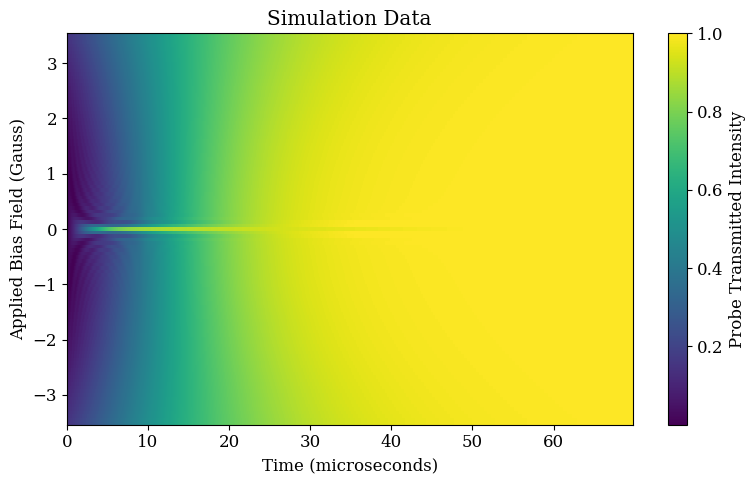

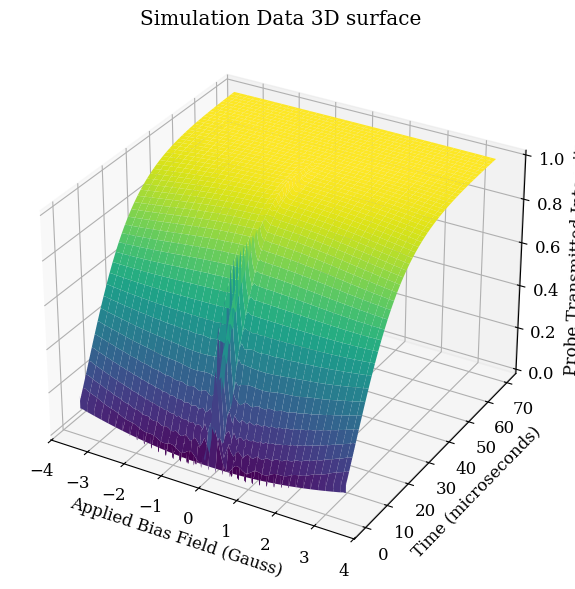

Exp Data


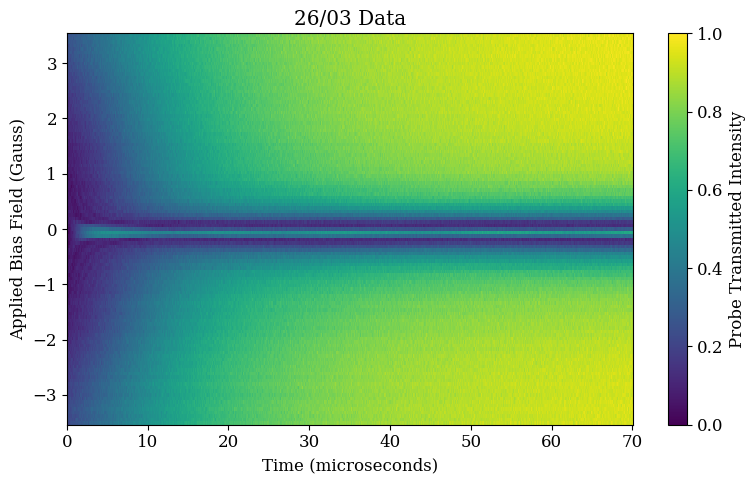

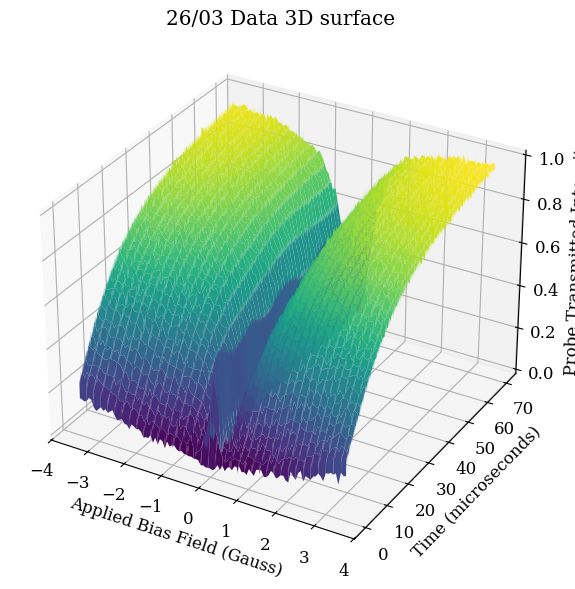

In [22]:
sim_matrix = get_predictions_batch(sim_spline, cp.asarray(t_sim), cp.asarray(f_bias_axis), cp.asarray([0.0, 0.05,0.1,0.15,0.2,0.25,0.3]), mode = "Longitudinal Likelihood")
print("Sim Data")
plot_heat_and_surface(t_sim.get(),f_bias_axis, sim_matrix[:,:, 0].get(), title_prefix="Simulation Data")
print("Exp Data")
plot_heat_and_surface(t_exp, f_bias_axis+F_BIAS_OFFSET_NUISANCE, exp_matrix, title_prefix = "26/03 Data")

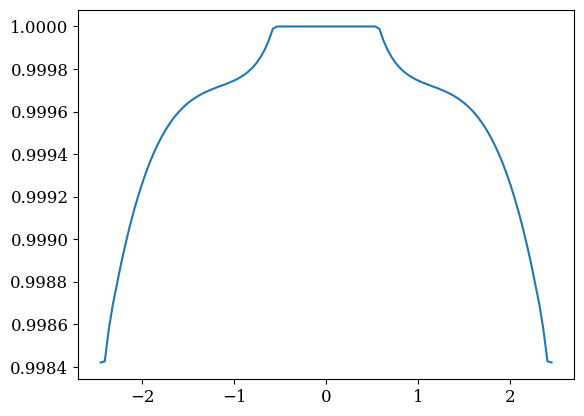

In [23]:
plt.plot(f_bias_axis,sim_matrix[:, :, 0].get()[-1,:])

Difference Plot between Simulation and Experiment

In [ ]:
sim_matrix = get_predictions_batch(sim_spline, cp.asarray(t_exp), cp.asarray(f_bias_axis), cp.asarray([0.12, 0.3]), mode = "Longitudinal Likelihood")
d_sim_matrix = cp.diff(sim_matrix, axis=0)
print("Sim Data", 0.09)
plot_heat_and_surface(t_exp, f_bias_axis+F_BIAS_OFFSET_NUISANCE, sim_matrix[:,:, 0].get() -exp_matrix, title_prefix="Difference")#calibration(sim_matrix - exp_matrix, np.min(sim_matrix - exp_matrix), np.max(sim_matrix - exp_matrix)))

In [ ]:
T_STEP = 0.2
MAX_TIME = 70
fixed_bz_estimate = cp.array([-1*B_unk_bound_longitudinal, 0.045, 1*B_unk_bound_longitudinal]) 
for i in range(0,2, 2):
    curr_time = 20 + i

    Test = f"_0.3_threshold_curr_time_{curr_time}_max_time_{MAX_TIME}_t_step_{T_STEP}_fixed_bz_0.045_by_0.12"
    new_dir = f"Results\\Dataset_8\\3_Apr\\Protocol_Comparison_Test_One_Iter\\Random_Selection\\curr_time_{curr_time}"
    # new_dir_y = f"Results\\Dataset_7\\23_Mar\\Protocol_Comparison_Test_One_Iter\\Adaptive_Selection"
    os.makedirs(new_dir, exist_ok=True)
    # os.makedirs(new_dir_y, exist_ok=True)
    results_y_estimation = run_experiment_y_estimation(Test = Test, fixed_bz_estimate = 0.045, curr_time = curr_time)
    current_by = results_y_estimation["est"][-1]
    current_by_std = results_y_estimation["stddev"][-1]
    fixed_by_estimate = cp.array([max(params.B_unk_bound_transverse_lower,current_by - 1*current_by_std), current_by, min(params.B_unk_bound_transverse_upper,current_by + 1*current_by_std)])
    results_longitudinal_estimation = run_experiment_longitudinal_estimation(Test = Test, fixed_by_estimate = 0.12, curr_time = curr_time, print_plot= False)

In [ ]:
results_y_estimation = run_experiment_y_estimation(Test = Test, fixed_bz_estimate = 0.045, curr_time = curr_time)

In [ ]:
results_longitudinal_estimation = run_experiment_longitudinal_estimation(Test = Test, fixed_by_estimate = 0.12760, curr_time = curr_time, print_plot= False)

Checking  Results for Various T_STEP - Make note of directory and name of file saved - when trying to load teh results for the same

In [ ]:
'''t_step = [i/10 for i in range(15, 100, 5)]
for T_STEP in t_step:
    MAX_TIME = 30
    # if T_STEP>=1: zoom_factor = 3
    results_longitudinal_estimation = run_experiment_longitudinal_estimation(fixed_by_estimate = 0.12, curr_time = 0)#, zoom_factor = zoom_factor)
    t,est,stddev,bias,res,posteriors,bgrid,expectedkl = results_longitudinal_estimation['time'], results_longitudinal_estimation['est'],results_longitudinal_estimation['stddev'], results_longitudinal_estimation['bias'], results_longitudinal_estimation['res'], results_longitudinal_estimation['posteriors'], results_longitudinal_estimation['bgrids'], results_longitudinal_estimation['expectedkl']
    result_longitudinal_estimation = {
    'time':np.array(t), 
    'est':np.array(est), 
    'stddev':np.array(stddev), 
    'bias':np.array(bias), 
    'res':np.array(res), 
    'posteriors':np.array(posteriors, dtype=object), 
    'bgrids':np.array(bgrid, dtype=object), 
    'expectedkl':np.array(expectedkl, dtype=object)
    }
    np.savez_compressed(f"Tests/Actual/CW/Test_{Test}/Test_{Test}_results_longitudinal_estimation_T_STEP_{T_STEP}.npz", **result_longitudinal_estimation)
    print(f"Results for t_step {T_STEP} saved successfully.")
print("results saved succcesfully")'''

Loading Results for the longitdinal estimation - Please verify test variable value and the address in np.load to ensure the right result is loaded

In [ ]:
'''Test = "Old_Experiment_Data_Dataset_3_New_Normalisation_Linear_Interpolator"
T_STEP = 0.5
result_longitudinal_estimation = np.load(f"Tests/Actual/CW/Test_Old_Experiment_Data_Dataset_3_New_Normalisation_Linear_Interpolator/Test_Old_Experiment_Data_Dataset_3_New_Normalisation_Linear_Interpolator_results_longitudinal_estimation.npz", allow_pickle=True)
t,est,stddev,bias,res,posteriors,bgrid,expectedkl = result_longitudinal_estimation['time'], result_longitudinal_estimation['est'],result_longitudinal_estimation['stddev'], result_longitudinal_estimation['bias'], result_longitudinal_estimation['res'], result_longitudinal_estimation['posteriors'], result_longitudinal_estimation['bgrids'], result_longitudinal_estimation['expectedkl']
print("Results data loaded successfully.")
exp_trace_0 = exp_matrix[:,0].flatten()
print(exp_trace_0.shape)
plot_heat_and_surface(t_exp, f_bias_axis, exp_matrix, trajectory_mode=True,traj_bias = bias, estimation_mode = 'longitudinal')
'''

In [ ]:
'''final_posterior = posteriors[-1]
print(est[-1], stddev[-1])
area = np.trapezoid(final_posterior, x = bgrid[-1])
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(bgrid[-1], final_posterior, label="final posterior", marker = '.')
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(
    bgrid[-1][np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()'''

Gif: Posterior

In [ ]:
'''# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Magnetic Field B")
ax.set_ylabel("Posterior Probability")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = bgrid[frame]
    y = posteriors[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Posterior Step {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(posteriors), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Test_{Test}/posterior_evolution.gif', writer='pillow', fps=4)

plt.show()'''

Gif: KL Divergence

In [ ]:
'''# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Bias Field")
ax.set_ylabel("Expected KL Divergence")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = f_bias_axis
    y = expectedkl[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Expected_KL {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(expectedkl), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Test_{Test}/KL_Divergence.gif', writer='pillow', fps=4)

plt.show()'''

Mode and Std Dev Convergence

In [ ]:
'''save_path = os.path.join(new_dir, f'Mode Convergence MAP Test {Test}.png'.format(Test))
plt.plot([i for i in range(len(est))], est, label=f"Mode Convergence", marker = '.')
plt.xlabel("N_exp")
plt.ylabel("Mode")
plt.title("Mode Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()


save_path = os.path.join(new_dir, f'Std Convergence MAP Test {Test}.png'.format(Test))
plt.plot([i for i in range(len(stddev))], stddev, label=f"Standard Deviation Convergence", marker = '.')
plt.xlabel("N_exp")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()'''


Ok, Y field estimation by interpolation test.... First we'll have a look at the datasets together and try an interpolation method, measure accuracy and then try the same estimation procedure. 

In [ ]:
t_sim, f_sim, by_sim, sim_cube = load_simulation_cube(SIM_FILES_CONFIG_Y_Estimation)
print("Sim Cube shape:", sim_cube.shape)

In [ ]:
interact(plot_slice, by_idx=IntSlider(min=0, max=len(by_sim)-1, step=1, value=0));

Okay, here we validate the interpolation method. The logic is to check for measure of good fit by leaving a point out in each iteration and extrapolating its value from the rest and seeing how well the prediction is. An average is taken over each such iteration corresponding to each point in the domain.

In [ ]:
validate_interpolator(t_sim, f_sim, by_sim, sim_cube)

In [ ]:
t_sim, f_sim, by_sim,sim_interp = get_final_interpolator(SIM_FILES_CONFIG_Y_Estimation)

Plotting Interpolator Predictions

In [ ]:
y_vals = cp.linspace(0, 0.4, 10)
Z_mesh, Y_mesh = cp.meshgrid(f_sim, y_vals, indexing='ij')
T_mesh = cp.full_like(Z_mesh, t_sim[-1])
predictions = sim_interp.interpolate(T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten())
predictions = predictions.reshape(Z_mesh.shape)

plt.figure(figsize=(10,10))
for i in range(len(y_vals)):
    plt.plot(f_sim.get(), predictions[:,i].get(), label=f'Y_val {float(y_vals[i])}', marker = '.')
    plt.ylabel("Normalised Intensity")
    plt.xlabel("Longitudinal Field")
    if i%5==0: plt.legend()
    plt.title("Interpolator Predictions at Final Time Slice, steady state")
plt.show()

In [ ]:
y_vals = cp.linspace(0, 0.4, 100)
y_vals_1 = by_sim
Z_mesh, Y_mesh = cp.meshgrid(f_sim, y_vals, indexing='ij')
T_mesh = cp.full_like(Z_mesh, t_sim[-1])
Z_mesh_1, Y_mesh_1 = cp.meshgrid(f_sim, y_vals_1, indexing='ij')
T_mesh_1 = cp.full_like(Z_mesh_1, t_sim[-1])
predictions = sim_interp.interpolate(T_mesh.flatten(), Z_mesh.flatten(), Y_mesh.flatten())
predictions = predictions.reshape(Z_mesh.shape)
predictions_1 = sim_interp.interpolate(T_mesh_1.flatten(), Z_mesh_1.flatten(), Y_mesh_1.flatten())
predictions_1 = predictions_1.reshape(Z_mesh_1.shape)

for i in range(0,len(f_sim),10):
    plt.plot(y_vals.get(), predictions[i,:].get(), label=f'Interpolator Predictions {f_sim[i]}', marker = '.')
    plt.plot(y_vals_1.get(), predictions_1[i,:].get(), marker = 'o', label ='Simulation Data Set Points')

plt.ylabel("Normalised Intensity")
plt.xlabel("Transverse Y Field")
plt.title("Interpolator Predictions at Final Time Slice for fixed Longitudinal Field ~0")
#plt.legend()
plt.show()

Transverse Field Estimation for Various Time Steps - Minor Modifications to the code to save files appropriately are required - 18/01/2026

In [ ]:
'''t_step = [i/10 for i in range(5, 100, 5)]
for T_STEP in t_step:
    MAX_TIME = 30
    if T_STEP>=1:
        zoom_factor = ZOOM_FACTOR**(T_STEP**0.5)
    results_y_estimation = run_experiment_y_estimation(fixed_bz_estimate = 0.12, curr_time = 0, zoom_factor = zoom_factor)
    t,est,stddev,bias,res,posteriors,bgrid,expectedkl = results_y_estimation['time'], results_y_estimation['est'],results_y_estimation['stddev'], results_y_estimation['bias'], results_y_estimation['res'], results_y_estimation['posteriors'], results_y_estimation['bgrids'], results_y_estimation['expectedkl']
    result_y_estimation = {
    'time':np.array(t), 
    'est':np.array(est), 
    'stddev':np.array(stddev), 
    'bias':np.array(bias), 
    'res':np.array(res), 
    'posteriors':np.array(posteriors, dtype=object), 
    'bgrids':np.array(bgrid, dtype=object), 
    'expectedkl':np.array(expectedkl, dtype=object)
    }
    np.savez_compressed(f"Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Test_{Test}_results_y_estimation_T_STEP_{T_STEP}.npz", **result_y_estimation)
    print(f"Results for t_step {T_STEP} saved successfully.")
print("results saved succcesfully")'''

Loading Results for the transverse estimation - Please verify test variable value and the address in np.load to ensure the right result is loaded

In [ ]:
'''Test = "New_Experiment_Data_Dataset_3_trial_4"
T_STEP = 0.5
result_longitudinal_estimation = np.load(f"Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Test_{Test}_results_y_estimation_T_STEP_{T_STEP}.npz", allow_pickle=True)
t,est,stddev,bias,res,posteriors,bgrid,expectedkl = result_longitudinal_estimation['time'], result_longitudinal_estimation['est'],result_longitudinal_estimation['stddev'], result_longitudinal_estimation['bias'], result_longitudinal_estimation['res'], result_longitudinal_estimation['posteriors'], result_longitudinal_estimation['bgrids'], result_longitudinal_estimation['expectedkl']
print("Results data loaded successfully.")
exp_trace_0 = exp_matrix[:,0].flatten()
print(exp_trace_0.shape)
t_exp_0, __ = find_pulse_start(exp_trace_0, t_exp, EXP_PULSE_THRESH)
plot_heat_and_surface((t_exp[__:]-t_exp_0), f_bias_axis, exp_matrix[__:,], trajectory_mode=True,traj_bias = bias)
print(bias)
print(f_bias_axis)'''

In [ ]:
'''final_posterior = posteriors[-1]
print(est[-1], stddev[-1])
area = np.trapezoid(final_posterior, x = bgrid[-1])
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(bgrid[-1][np.argmax(final_posterior) - 1000:np.argmax(final_posterior)+1000], final_posterior[np.argmax(final_posterior) - 1000:np.argmax(final_posterior)+1000], label="final posterior", marker = '.')
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(
    bgrid[-1][np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()'''

Posterior GIF

In [ ]:
'''# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Transverse Magnetic Field B")
ax.set_ylabel("Posterior Probability")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = bgrid[frame]
    y = posteriors[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Posterior Step {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(posteriors), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Transverse_field_posterior_evolution.gif', writer='pillow', fps=4)

plt.show()'''

KL Divergence GIF

In [ ]:
'''# Setup figure
fig, ax = plt.subplots(figsize=(8, 6))
line, = ax.plot([], [], lw=2)
ax.set_xlabel("Bias Field")
ax.set_ylabel("Expected KL Divergence")
ax.grid(True)

# Initialization function
def init():
    line.set_data([], [])
    return line,

# Animation update function
def update(frame):
    # Assuming bgrid and posteriors are lists/arrays of length 90
    x = f_bias_axis
    y = expectedkl[frame]
    
    # Update data
    line.set_data(x, y)
    
    # Rescale axes dynamically to fit the new zoomed/peaked distribution
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(0, y.max() * 1.1)
    ax.set_title(f"Expected_KL {frame}")
    return line,

# Create animation (interval in milliseconds)
anim = FuncAnimation(fig, update, frames=len(expectedkl), 
                     init_func=init, blit=False, interval=100)

# Option 2: Save as GIF (No external dependencies usually)
anim.save(f'Tests/Actual/CW/Transverse_Field_Estimation/Test_{Test}/Transverse_Field_KL_Divergence.gif', writer='pillow', fps=4)

plt.show()'''

Summary Stats

In [ ]:
'''save_path = os.path.join(new_dir_y, f'Mode Convergence MAP Transverse Field.png'.format(Test))
plt.plot(t, est, label=f"Mode Convergence")
plt.xlabel("Time (microseconds)")
plt.ylabel("Mode")
plt.title("Mode Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()


save_path = os.path.join(new_dir_y, f'Std Convergence MAP Transverse Field.png'.format(Test))
plt.plot(t, stddev, label=f"Standard Deviation Convergence")
plt.xlabel("Time (microseconds)")
plt.ylabel("Standard Deviation")
plt.title("Standard Deviation Convergence over experiments - Bayesian")
plt.savefig(save_path)
plt.show()'''
